# ECLIPSE — Complete Pipeline (All-in-One)

Runs the full ECLIPSE pipeline in one notebook:
**Part I** (darkness estimation) → **Part II** (two-track stratification) → **Part III** (DPPS scoring).

> The MMseqs2 `easy-search` is run separately on the command line and produces the
> `.m8` file used as input here (set `M8_FILE` in the config cell below).
> After running once, you can change a parameter (e.g. DPPS weights, length filter)
> and re-execute only the relevant Part III cells — the intermediate files are cached on disk.

**Prereqs:** Python 3 (pandas, numpy, matplotlib, seaborn, biopython, scipy, tqdm),
the `.m8` search output, the Atlas brightness/taxonomy files, and a local MMseqs2 (Part III clustering).


## 1. Configuration (edit once)

In [1]:
# =====================================================================
# CROSS-PLATFORM BOOTSTRAP  (Linux / macOS / Windows)  -- run this FIRST
# =====================================================================
# Anchors the working directory to the folder that holds the input data,
# so every relative "./..." path in this notebook resolves correctly no
# matter where Jupyter/VS Code was launched from. Also locates the
# MMseqs2 executable in an OS-appropriate way.
# ---------------------------------------------------------------------
import os, sys, platform, shutil, subprocess
from pathlib import Path

# --- 1. Locate the data directory -----------------------------------
# A valid data dir contains a "faa" folder and at least one ".m8" file.
def _is_data_dir(p: Path) -> bool:
    return (p / "faa").is_dir() and any(p.glob("*.m8"))

_start = Path.cwd().resolve()
_candidates = [_start, _start / "test_data", *_start.parents[:3]]
_candidates += [p / "test_data" for p in _start.parents[:3]]

BASE_DIR = next((p for p in _candidates if _is_data_dir(p)), None)

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not locate the ECLIPSE data directory.\n"
        "Expected a folder containing a 'faa/' subfolder and a '*.m8' file.\n"
        f"Searched from: {_start}\n"
        "Fix: set BASE_DIR manually, e.g.\n"
        "    BASE_DIR = Path(r'C:/Users/you/ECLIPSE/test_data')   # Windows\n"
        "    BASE_DIR = Path('/home/you/ECLIPSE/test_data')       # Linux/macOS\n"
        "then re-run this cell."
    )

os.chdir(BASE_DIR)
print(f"OS              : {platform.system()} ({platform.machine()})")
print(f"Python          : {sys.version.split()[0]}")
print(f"Working dir     : {BASE_DIR}")

# --- 2. Locate MMseqs2 ----------------------------------------------
# Windows ships a 'mmseqs.bat' wrapper (Cygwin-based beta build); Linux
# and macOS use the plain 'mmseqs' binary. WSL2 is the recommended route
# on Windows. shutil.which() resolves the full path, which lets
# subprocess.run() invoke a .bat correctly without shell=True.
def _find_mmseqs():
    for name in ("mmseqs", "mmseqs.bat", "mmseqs.exe"):
        found = shutil.which(name)
        if found:
            return found
    return None

MMSEQS_BIN = _find_mmseqs()

if MMSEQS_BIN:
    print(f"MMseqs2         : {MMSEQS_BIN}")
else:
    print("MMseqs2         : NOT FOUND on PATH")
    print("  Install with any of:")
    print("    conda install -c conda-forge -c bioconda mmseqs2   # Linux/macOS")
    print("    brew install mmseqs2                               # macOS")
    print("  Windows: use WSL2 (recommended) or the Cygwin-based Windows")
    print("  build, keeping mmseqs.bat one folder above its bin/ directory.")
    print("  Clustering cells will raise a clear error until this is resolved.")

# --- 3. Text-file I/O defaults --------------------------------------
# Windows defaults to cp1252 + CRLF translation. Force UTF-8 / LF so that
# FASTA files written here are byte-identical across all three OSes.
TEXT_KW = dict(encoding="utf-8", newline="\n")
print("Text I/O        : UTF-8, LF line endings (enforced)")
print("Bootstrap complete.")


OS              : Darwin (x86_64)
Python          : 3.12.4
Working dir     : /Users/sla24/Dark_node-manuscript/all in one
MMseqs2         : /opt/homebrew/bin/mmseqs
Text I/O        : UTF-8, LF line endings (enforced)
Bootstrap complete.


In [2]:
# ===== CONFIG (edit once) =====
GENUS        = "Pseudomonas"
SPECIES      = "Pseudomonas aeruginosa"
SPECIES_COL  = "p_aeruginosa_proportion"
SPECIES_ABBR = "PA"
FAA_DIR      = "./faa"
M8_FILE      = "./PA.m8"          # MMseqs2 easy-search result (.m8)
MIN_SEQ_LEN  = 300
# inter-stage filenames
PART1_OUTPUT = "eclipse_seq.csv"
INPUT_CSV    = PART1_OUTPUT       # Part II reads Part I output (seam fixed)
PS_OUT_CSV   = "./mapped_p_aer_dataset_pseudomonas_specific_dark_components.csv"
ES_OUT_CSV   = "./mapped_p_aer_dataset_eskape_enriched_dark_components.csv"
PS_CSV       = PS_OUT_CSV
ES_CSV       = ES_OUT_CSV
MMSEQS_MIN_SEQ_ID = 0.3
MMSEQS_COVERAGE   = 0.8
MMSEQS_TMP        = "./tmp_mmseqs"

# ===== ALL IMPORTS =====
from Bio import SeqIO
from collections import Counter
import collections
import gzip
import io
import json
import math
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import os
import os, re
import pandas as pd
import random
import re
import seaborn as sns
import shutil
import subprocess
import subprocess as sp
import sys
import time
import tqdm
import warnings
import yaml
import zipfile
print("Config + imports loaded for:", SPECIES)

Config + imports loaded for: Pseudomonas aeruginosa


## 2. Part I — Darkness Estimation

Loads the MMseqs2 `.m8` result, maps to Atlas communities/components, computes brightness, extracts dark proteome, taxonomic diversity.

In [3]:
# -- UNIVERSAL CONFIG -- change only this line for each new pathogen --------
M8_FILE = './PA.m8'   # path to your MMseqs2 .m8 search result file
#   e.g. './SA.m8' for S. aureus, './KP.m8' for K. pneumoniae, etc.
# -------------------------------------------------------------------------

# load mmseqs2 alignment results
atlas_search_results_info = [M8_FILE]

atlas_search_results = None

for f in atlas_search_results_info:
    print(f)
    atlas_search_results = pd.read_csv(
        f, sep='\t',
        names=['queryID', 'targetID', 'fident', 'alnlen', 'mismatch',
               'gapopen', 'qstart', 'qend', 'tstart', 'tend', 'eVal', 'bits']
    )

atlas_search_results  # here 'targetIDs' are UniRef50 representatives from the atlas

./PA.m8


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits
0,QLX61_RS27085,W9SYN9,0.940,355,21,0,4,358,3,356,2.248000e-223,697
1,M0418_RS10560,A0A109LHD2,0.821,397,71,0,1,397,1,397,1.899000e-215,670
2,M0418_RS10720,A0A2W0B2F2,0.358,224,143,0,15,237,13,236,5.420000e-27,121
3,M0418_RS23985,A0A259UNW9,0.322,421,285,0,9,429,9,429,7.784000e-68,245
4,M0418_RS24145,A0A1J4XIL7,0.421,147,84,0,1,147,1,146,5.899000e-25,107
...,...,...,...,...,...,...,...,...,...,...,...,...
3460652,M2I89_RS25900,A0A5C7LXQ1,0.442,165,92,0,1,165,19,183,9.854000e-27,113
3460653,M2I89_RS31675,A0A7Y1FVV3,0.593,160,65,0,1,160,1,160,1.580000e-45,167
3460654,M2I89_RS31835,A0A0H3YTV6,0.800,95,19,0,1,95,1,95,9.545000e-46,164
3460655,PALA22_RS09530,A0A2V6IGP8,0.413,104,60,0,49,152,1,104,1.069000e-19,92


In [4]:
#drop duplicates queryIDs in atlas_search_results

atlas_search_results = atlas_search_results.drop_duplicates(subset='queryID')
atlas_search_results

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits
0,QLX61_RS27085,W9SYN9,0.940,355,21,0,4,358,3,356,2.248000e-223,697
1,M0418_RS10560,A0A109LHD2,0.821,397,71,0,1,397,1,397,1.899000e-215,670
2,M0418_RS10720,A0A2W0B2F2,0.358,224,143,0,15,237,13,236,5.420000e-27,121
3,M0418_RS23985,A0A259UNW9,0.322,421,285,0,9,429,9,429,7.784000e-68,245
4,M0418_RS24145,A0A1J4XIL7,0.421,147,84,0,1,147,1,146,5.899000e-25,107
...,...,...,...,...,...,...,...,...,...,...,...,...
3460652,M2I89_RS25900,A0A5C7LXQ1,0.442,165,92,0,1,165,19,183,9.854000e-27,113
3460653,M2I89_RS31675,A0A7Y1FVV3,0.593,160,65,0,1,160,1,160,1.580000e-45,167
3460654,M2I89_RS31835,A0A0H3YTV6,0.800,95,19,0,1,95,1,95,9.545000e-46,164
3460655,PALA22_RS09530,A0A2V6IGP8,0.413,104,60,0,49,152,1,104,1.069000e-19,92


In [5]:
# load all the atlas data 
# it excludes anything uniparc

# MEMORY FIX: load only the columns used downstream instead of the full ~4 GB file.
# The atlas CSVs have many columns; the notebook only ever uses these five
# (componentIDs is derived from communityIDs in the next cell).
usecols = ['UniRef50IDs', 'communityIDs', 'genus', 'species', 'brightness']

atlas_datafiles = ['AFDB90v4_cc_data_uniprot_community_taxonomy_map_with_brightness.csv',
                   'AFDB90v4_dust_uniprot_community_taxonomy_map_with_brightness.csv']

frames = []
for f in atlas_datafiles:
    print(f)
    label = f.split('AFDB90v4_')[-1].split('_')[0]
    df = pd.read_csv(f, sep=',', usecols=usecols)
    df['label'] = label
    frames.append(df)

atlas_data = pd.concat(frames, axis=0, ignore_index=True)
del frames  # release the per-file copies so peak memory stays low

# brightness -> float32 (harmless if already numeric); trims memory further
atlas_data['brightness'] = pd.to_numeric(atlas_data['brightness'], downcast='float')

atlas_data

AFDB90v4_cc_data_uniprot_community_taxonomy_map_with_brightness.csv
AFDB90v4_dust_uniprot_community_taxonomy_map_with_brightness.csv


,genus,species,UniRef50IDs,communityIDs,brightness,label
0,Corynebacterium,Corynebacterium amycolatum,UniRef50_E2MW64,1920284[0],96.680000,cc
1,Acinetobacter,Acinetobacter haemolyticus,UniRef50_N9TGA3,21487[0],99.089996,cc
2,Acinetobacter,Acinetobacter genomosp. 16BJ,UniRef50_N9TGA3,21487[0],99.089996,cc
3,Acinetobacter,Acinetobacter sp. ETR1,UniRef50_N8WWZ2,51933[0],86.730003,cc
4,Acinetobacter,Acinetobacter guillouiae,UniRef50_N8WWZ2,51933[0],86.730003,cc
...,...,...,...,...,...,...
38500629,Haptolina,Haptolina brevifila,UniRef50_A0A7S2D1G0,1612739[0],66.959999,dust
38500630,Bradyrhizobium,Bradyrhizobium sp. CCBAU 51765,UniRef50_A0A7S7T862,1627339[0],86.500000,dust
38500631,Clytia,Clytia hemisphaerica,UniRef50_A0A7M5WQ56,1597478[0],98.959999,dust
38500632,Clytia,Clytia hemisphaerica,UniRef50_A0A7M5WQ56,1597478[0],98.959999,dust


In [6]:
# drop 'UniRef50_' in UniRef50ID names and add componentIDs 

atlas_data['UniRef50IDs'] = atlas_data['UniRef50IDs'].apply(lambda x: x.split('_')[1])
atlas_data['componentIDs'] = atlas_data['communityIDs'].apply(lambda x: x.split('[')[0]).astype('int64')

atlas_data

,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs
0,Corynebacterium,Corynebacterium amycolatum,E2MW64,1920284[0],96.680000,cc,1920284
1,Acinetobacter,Acinetobacter haemolyticus,N9TGA3,21487[0],99.089996,cc,21487
2,Acinetobacter,Acinetobacter genomosp. 16BJ,N9TGA3,21487[0],99.089996,cc,21487
3,Acinetobacter,Acinetobacter sp. ETR1,N8WWZ2,51933[0],86.730003,cc,51933
4,Acinetobacter,Acinetobacter guillouiae,N8WWZ2,51933[0],86.730003,cc,51933
...,...,...,...,...,...,...,...
38500629,Haptolina,Haptolina brevifila,A0A7S2D1G0,1612739[0],66.959999,dust,1612739
38500630,Bradyrhizobium,Bradyrhizobium sp. CCBAU 51765,A0A7S7T862,1627339[0],86.500000,dust,1627339
38500631,Clytia,Clytia hemisphaerica,A0A7M5WQ56,1597478[0],98.959999,dust,1597478
38500632,Clytia,Clytia hemisphaerica,A0A7M5WQ56,1597478[0],98.959999,dust,1597478


In [7]:
#sort values in the atlas_search_results by targetID

atlas_search_results.sort_values(by='targetID', inplace=True)
atlas_search_results

/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_91480/752831130.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results.sort_values(by='targetID', inplace=True)


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits
599410,A6R75_RS04155,A0A009EQY8,0.550,40,18,0,5,44,14,53,2.142000e-06,51
1243866,BFV99_RS29425,A0A009EQY8,0.380,42,25,0,2,43,12,53,4.523000e-04,46
3109409,Y82_RS05740,A0A009EQY8,0.380,42,25,0,2,43,12,53,2.134000e-05,46
305126,IOMTU133_RS01595,A0A009EQY8,0.550,40,18,0,5,44,14,53,2.142000e-06,51
524532,PMJ92_RS11905,A0A009EQY8,0.511,45,22,0,19,63,9,53,1.081000e-06,53
...,...,...,...,...,...,...,...,...,...,...,...,...
1955936,M8G39_RS12530,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222
2062461,PALA44_RS18320,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222
621706,EL342_RS21235,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222
322347,FOY97_RS12080,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222


In [8]:
# Select only those UniRef50 representatives in the atlas data that are in atlas_search_results and drop duplicates

atlas_data_selected = atlas_data.loc[atlas_data['UniRef50IDs'].isin(atlas_search_results['targetID'])]
atlas_data_selected = atlas_data_selected.drop_duplicates(subset='UniRef50IDs')
atlas_data_selected.sort_values(by='UniRef50IDs', inplace=True)
atlas_data_selected

,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs
19772366,Acinetobacter,Acinetobacter baumannii,A0A009EQY8,0[64256],94.580002,cc,0
35370175,Acinetobacter,Acinetobacter sp. 479375,A0A009ZFP6,242909[0],0.000000,dust,242909
19928362,Pseudomonas,Pseudomonas fluorescens,A0A010RHE6,0[7537],82.809998,cc,0
35390193,Pseudomonas,Pseudomonas fluorescens,A0A010RPD7,242944[0],0.000000,dust,242944
35389450,Pseudomonas,Pseudomonas fluorescens,A0A010RVP0,242950[0],39.810001,dust,242950
...,...,...,...,...,...,...,...
36419377,Roseivivax,Roseivivax halodurans,X7E826,2108109[0],0.000000,dust,2108109
36440327,Roseivivax,Roseivivax isoporae,X7F381,2108185[0],0.000000,dust,2108185
36420378,Pilimelia,Pilimelia anulata,X8AAB5,2108296[0],0.000000,dust,2108296
36426591,Streptococcus,Streptococcus milleri,X8H8H1,2108502[0],0.000000,dust,2108502


In [9]:
# map communityID to each targetID in the atlas_search_results

communityID = []
previous_targetID = ''

for targetID in tqdm.tqdm(atlas_search_results['targetID'], total=len(atlas_search_results), desc=' ... Collecting targetID counts', bar_format="{l_bar}{bar}{r_bar} [ time left: {remaining}, time spent: {elapsed}]", position=0, leave=True):
    
    if targetID != previous_targetID:
        
        cur_communityID = atlas_data_selected['communityIDs'].loc[atlas_data_selected['UniRef50IDs'] == targetID].values[0]
        previous_targetID = targetID
    
    communityID.append(cur_communityID)


atlas_search_results_maped = atlas_search_results.copy()

atlas_search_results_maped['communityID'] = communityID
atlas_search_results_maped

 ... Collecting targetID counts: 100%|██████████| 3457506/3457506 [00:15<00:00, 227507.07it/s] [ time left: 00:00, time spent: 00:15]


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID
599410,A6R75_RS04155,A0A009EQY8,0.550,40,18,0,5,44,14,53,2.142000e-06,51,0[64256]
1243866,BFV99_RS29425,A0A009EQY8,0.380,42,25,0,2,43,12,53,4.523000e-04,46,0[64256]
3109409,Y82_RS05740,A0A009EQY8,0.380,42,25,0,2,43,12,53,2.134000e-05,46,0[64256]
305126,IOMTU133_RS01595,A0A009EQY8,0.550,40,18,0,5,44,14,53,2.142000e-06,51,0[64256]
524532,PMJ92_RS11905,A0A009EQY8,0.511,45,22,0,19,63,9,53,1.081000e-06,53,0[64256]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1955936,M8G39_RS12530,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222,0[187267]
2062461,PALA44_RS18320,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222,0[187267]
621706,EL342_RS21235,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222,0[187267]
322347,FOY97_RS12080,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222,0[187267]


In [10]:
# map brightness value to each communityID in the atlas_search_results
# here and below brightness and darkness are used for the same values

atlas_search_results_maped.sort_values(by='communityID', inplace=True)
atlas_data_selected.sort_values(by='communityIDs', inplace=True)

brightness = []

previous_communityID = ''

for communityID in tqdm.tqdm(atlas_search_results_maped['communityID'], total=len(atlas_search_results_maped), desc=' ... Collecting communityID counts', bar_format="{l_bar}{bar}{r_bar} [ time left: {remaining}, time spent: {elapsed}]", position=0, leave=True):
    
    if communityID != previous_communityID:
        
        cur_brightness = atlas_data_selected['brightness'].loc[atlas_data_selected['communityIDs'] == communityID].values[0]
        previous_communityID = communityID
    
    brightness.append(cur_brightness)

atlas_search_results_maped['brightness'] = brightness
atlas_search_results_maped

 ... Collecting communityID counts: 100%|██████████| 3457506/3457506 [00:13<00:00, 265780.58it/s] [ time left: 00:00, time spent: 00:13]


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness
632422,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.320000
507016,MMZ72_RS22095,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.320000
2405150,LXN03_RS16670,A0A072ZHN0,0.994,193,1,0,1,193,1,193,6.246000e-124,394,0[100010],98.440002
2200131,OSZ59_RS12480,A0A072ZHN0,0.994,193,1,0,1,193,1,193,1.174000e-123,394,0[100010],98.440002
885217,LSP20_RS17400,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.440002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1904413,P7I96_RS13175,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.000000
1334974,JHW37_RS11750,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.000000
3263906,CWI23_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.000000
691901,CWI22_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.000000


In [11]:
# map the componentID to each targetIDs in the atlas_search_results_maped
# as in the communityID name the number before the square brackets is the componentID, we can simply take that number as the componentID 

atlas_search_results_maped['componentID'] = atlas_search_results_maped['communityID'].apply(lambda x: x.split('[')[0]).astype(int)
atlas_search_results_maped

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID
632422,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.320000,0
507016,MMZ72_RS22095,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.320000,0
2405150,LXN03_RS16670,A0A072ZHN0,0.994,193,1,0,1,193,1,193,6.246000e-124,394,0[100010],98.440002,0
2200131,OSZ59_RS12480,A0A072ZHN0,0.994,193,1,0,1,193,1,193,1.174000e-123,394,0[100010],98.440002,0
885217,LSP20_RS17400,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.440002,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1904413,P7I96_RS13175,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.000000,9
1334974,JHW37_RS11750,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.000000,9
3263906,CWI23_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.000000,9
691901,CWI22_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.000000,9


In [12]:
# load the components data 

components_datafiles = ['AFDB90v4_subgraphs_summary.csv']

components_data = None
for f in components_datafiles:
    print(f)
    
    components_data = pd.read_csv(f, sep=',')
        
components_data # here 'Subgraph' is componentID

AFDB90v4_subgraphs_summary.csv


,Subgraph,Avg_darkness,SD_darkness,N_members,TM,SP,Median_length,MAD_length,Median_darkness,MAD_darkness,N_communities
0,0,88.965221,22.034931,3036238,0.272574,0.272574,233.0,98.0,97.440,2.050,358579
1,1,88.189645,28.734713,1946,0.000000,0.000000,278.0,29.0,98.230,0.830,298
2,2,91.191058,11.996458,1871,2.030999,2.030999,493.0,49.0,95.000,2.020,301
3,3,83.702536,26.760281,1672,0.000000,0.000000,180.5,41.5,94.035,3.835,143
4,4,80.757456,26.934344,1490,0.000000,0.000000,139.0,7.0,94.160,3.705,213
...,...,...,...,...,...,...,...,...,...,...,...
242871,147996,98.270000,1.390000,2,0.000000,0.000000,223.5,94.5,98.270,1.390,1
242872,147995,0.000000,0.000000,2,0.000000,0.000000,184.0,0.0,0.000,0.000,1
242873,147994,0.000000,0.000000,2,0.000000,0.000000,326.0,76.0,0.000,0.000,1
242874,147993,0.000000,0.000000,2,0.000000,0.000000,226.0,90.0,0.000,0.000,1


In [13]:
# atlas_search_results_maped has UniRef50 representatives that belong to components that are upsent in components_data
# separate such UniRef50 representatives to a separate data frame

atlas_search_results_maped_without_componentID = atlas_search_results_maped.loc[~(atlas_search_results_maped['componentID'].isin(components_data['Subgraph']))]
atlas_search_results_maped_without_componentID

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID
2384440,BBX44_RS05790,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021
3455736,HW11_RS22910,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021
1597153,HW01_RS15140,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021
2002594,PMJ90_RS13005,A0A377BZV4,0.584,264,109,0,1,264,1,264,1.905000e-94,330,1000022[0],0.0,1000022
365371,PMJ94_RS14110,A0A377BZV4,0.584,264,109,0,1,264,1,264,1.905000e-94,330,1000022[0],0.0,1000022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166832,IPV46_RS15215,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972
560333,CS058_RS14935,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972
731828,JBL36_RS25885,A0A376TJA6,0.573,115,48,0,209,322,2,116,9.658000e-26,116,999972[0],0.0,999972
972267,HUK75_RS15370,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972


In [14]:
# separate those UniRef50 representatives that form components 

atlas_search_results_maped_with_componentID = atlas_search_results_maped.loc[atlas_search_results_maped['componentID'].isin(components_data['Subgraph'])]
atlas_search_results_maped_with_componentID

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID
632422,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.320000,0
507016,MMZ72_RS22095,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.320000,0
2405150,LXN03_RS16670,A0A072ZHN0,0.994,193,1,0,1,193,1,193,6.246000e-124,394,0[100010],98.440002,0
2200131,OSZ59_RS12480,A0A072ZHN0,0.994,193,1,0,1,193,1,193,1.174000e-123,394,0[100010],98.440002,0
885217,LSP20_RS17400,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.440002,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1904413,P7I96_RS13175,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.000000,9
1334974,JHW37_RS11750,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.000000,9
3263906,CWI23_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.000000,9
691901,CWI22_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.000000,9


In [15]:
#select target components from the component data 

components_data_selected = components_data.loc[components_data['Subgraph'].isin(atlas_search_results_maped_with_componentID['componentID'])]
components_data_selected

,Subgraph,Avg_darkness,SD_darkness,N_members,TM,SP,Median_length,MAD_length,Median_darkness,MAD_darkness,N_communities
0,0,88.965221,22.034931,3036238,0.272574,0.272574,233.0,98.0,97.440,2.050,358579
2,2,91.191058,11.996458,1871,2.030999,2.030999,493.0,49.0,95.000,2.020,301
3,3,83.702536,26.760281,1672,0.000000,0.000000,180.5,41.5,94.035,3.835,143
4,4,80.757456,26.934344,1490,0.000000,0.000000,139.0,7.0,94.160,3.705,213
5,5,96.206085,9.302048,1346,0.000000,0.000000,184.0,9.0,97.850,1.040,247
...,...,...,...,...,...,...,...,...,...,...,...
242291,147465,4.840000,4.840000,2,0.000000,0.000000,235.5,90.5,4.840,4.840,1
242384,148205,60.805000,2.495000,2,0.000000,0.000000,358.0,3.0,60.805,2.495,1
242540,148300,0.000000,0.000000,2,0.000000,0.000000,317.0,131.0,0.000,0.000,1
242859,148007,77.845000,13.695000,2,0.000000,0.000000,259.5,58.5,77.845,13.695,1


In [16]:
#add componentID median brightness to each component in the atlas_search_results_maped_with_componentID

atlas_search_results_maped_with_componentID.sort_values(by='componentID', inplace=True)

component_brightness = []
previous_componentID = ''

for componentID in tqdm.tqdm(atlas_search_results_maped_with_componentID['componentID'], total=len(atlas_search_results_maped_with_componentID), desc=' ... Collecting componentID counts', bar_format="{l_bar}{bar}{r_bar} [ time left: {remaining}, time spent: {elapsed}]", position=0, leave=True):
        
    if componentID != previous_componentID:
        
        cur_brightness = components_data_selected['Median_darkness'].loc[components_data_selected['Subgraph'] == componentID].values[0]
        previous_componentID = componentID
    
    component_brightness.append(cur_brightness)


atlas_search_results_maped_with_componentID['component_brightness'] = component_brightness
atlas_search_results_maped_with_componentID

/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_91480/1208085431.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results_maped_with_componentID.sort_values(by='componentID', inplace=True)
 ... Collecting componentID counts: 100%|██████████| 2870087/2870087 [00:00<00:00, 3699100.91it/s] [ time left: 00:00, time spent: 00:00]
/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_91480/1208085431.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results_maped_with_componentID['component_brightness'] = component_bright

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness
632422,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.320000,0,97.44
1638450,M8341_RS07390,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.570000,0,97.44
221718,CSC26_RS30115,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.570000,0,97.44
2045780,M0418_RS17410,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.570000,0,97.44
344606,MMG97_RS21935,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.570000,0,97.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1916968,KUU79_RS31925,T1D0U5,0.327,162,106,0,218,379,2,159,7.539000e-09,65,242095[0],97.529999,242095,82.52
77244,EGY27_RS02945,T1D0U5,0.327,162,106,0,218,379,2,159,7.539000e-09,65,242095[0],97.529999,242095,82.52
2612260,IE752_RS27135,T1D0U5,0.327,162,106,0,194,355,2,159,6.704000e-09,65,242095[0],97.529999,242095,82.52
2768925,CWI21_RS28970,T1D0U5,0.327,162,106,0,194,355,2,159,6.704000e-09,65,242095[0],97.529999,242095,82.52


In [17]:
# add component_brightness column in the atlas_search_results_maped_without_componentID df

atlas_search_results_maped_without_componentID['component_brightness'] = np.nan
atlas_search_results_maped_without_componentID

/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_91480/1510285853.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results_maped_without_componentID['component_brightness'] = np.nan


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness
2384440,BBX44_RS05790,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021,NaN
3455736,HW11_RS22910,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021,NaN
1597153,HW01_RS15140,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021,NaN
2002594,PMJ90_RS13005,A0A377BZV4,0.584,264,109,0,1,264,1,264,1.905000e-94,330,1000022[0],0.0,1000022,NaN
365371,PMJ94_RS14110,A0A377BZV4,0.584,264,109,0,1,264,1,264,1.905000e-94,330,1000022[0],0.0,1000022,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166832,IPV46_RS15215,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972,NaN
560333,CS058_RS14935,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972,NaN
731828,JBL36_RS25885,A0A376TJA6,0.573,115,48,0,209,322,2,116,9.658000e-26,116,999972[0],0.0,999972,NaN
972267,HUK75_RS15370,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972,NaN


In [18]:
# combine atlas_search_results_maped_with_componentID with atlas_search_results_maped_without_componentID into one data frame

atlas_search_results_maped_merged  = pd.concat([atlas_search_results_maped_with_componentID, atlas_search_results_maped_without_componentID], axis=0)

atlas_search_results_maped_merged # here if you see that for the targetID component_brightness to which this targetID belongs is NaN, it means that this targetID(=UniRef50 representative) belongs to a single community that does not form a component

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness
632422,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0,97.44
1638450,M8341_RS07390,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
221718,CSC26_RS30115,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
2045780,M0418_RS17410,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
344606,MMG97_RS21935,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166832,IPV46_RS15215,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.00,999972,NaN
560333,CS058_RS14935,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.00,999972,NaN
731828,JBL36_RS25885,A0A376TJA6,0.573,115,48,0,209,322,2,116,9.658000e-26,116,999972[0],0.00,999972,NaN
972267,HUK75_RS15370,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.00,999972,NaN


All n = 3457506 n_dark = 296755 %dark = 9


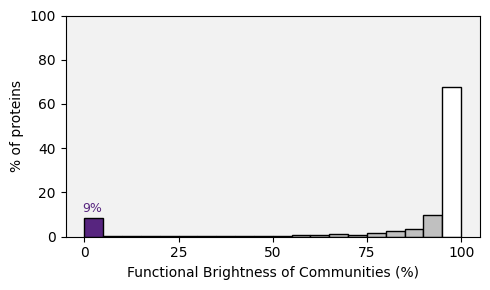

In [19]:
# make a histogram showing the percentage of dark communities to which queryIDs have been linked

fig, ax = plt.subplots(figsize=(5, 3))

tmp = atlas_search_results_maped_merged

# Compute histogram
h, _ = np.histogram(tmp.brightness.astype(float), bins=[i for i in range(0, 105, 5)])
n_dark = h[0]
h = h * 100 / sum(h)

# Colors for the bars
colors = ['#57257F'] + ['silver'] * (len(h) - 2) + ['white']

# X and Y values
x = (range(len(h)))
y = (h)

# Plotting the histogram
ax.bar(x, y, 1, align='edge', color=colors, edgecolor='k')
ax.set_facecolor('#F2F2F2')
ax.set_xticks(range(0, 21, 5))
ax.set_xticklabels(range(0, 101, 25))
ax.set_ylabel('% of proteins')
ax.set_xlabel('Functional Brightness of Communities (%)')

ax.set_ylim(0, 100)

percentage_dark = round(h[0])
ax.text(-0.1, percentage_dark + 1, '{}%'.format(percentage_dark),
        verticalalignment='bottom', horizontalalignment='left',
        color='#57257F', fontsize=9)

print('All', 'n =', len(tmp), 'n_dark =', n_dark, '%dark =', percentage_dark)

# Adjust layout and save the figure
plt.tight_layout()

plt.savefig('dark_communities.png', dpi=2000)
plt.show()

All n = 2870087 n_dark = 120985 %dark = 4


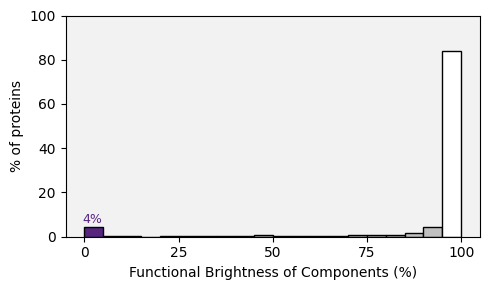

In [20]:
# make a histogram showing the percentage of dark components to which queryIDs have been linked

fig, ax = plt.subplots(figsize=(5, 3))

tmp = atlas_search_results_maped_with_componentID

# Compute histogram
h, _ = np.histogram(tmp.component_brightness.astype(float), bins=[i for i in range(0, 105, 5)])
n_dark = h[0]
h = h * 100 / sum(h)

# Colors for the bars
colors = ['#57257F'] + ['silver'] * (len(h) - 2) + ['white']

# X and Y values
x = (range(len(h)))
y = (h)

# Plotting the histogram
ax.bar(x, y, 1, align='edge', color=colors, edgecolor='k')
ax.set_facecolor('#F2F2F2')
ax.set_xticks(range(0, 21, 5))
ax.set_xticklabels(range(0, 101, 25))
ax.set_ylabel('% of proteins')
ax.set_xlabel('Functional Brightness of Components (%)')


ax.set_ylim(0, 100)

percentage_dark = round(h[0])
ax.text(-0.1, percentage_dark + 1, '{}%'.format(percentage_dark),
        verticalalignment='bottom', horizontalalignment='left',
        color='#57257F', fontsize=9)

print('All', 'n =', len(tmp), 'n_dark =', n_dark, '%dark =', percentage_dark)

# Adjust layout and save the figure
plt.tight_layout()

plt.savefig('components_darkness.png', dpi=2000)
plt.show()

In [21]:
# first delete all rows in the atlas data in which species and genus are equal to NaN 

atlas_data = atlas_data.loc[atlas_data['species'].notna()]
atlas_data = atlas_data.loc[atlas_data['genus'].notna()]
atlas_data

,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs
0,Corynebacterium,Corynebacterium amycolatum,E2MW64,1920284[0],96.680000,cc,1920284
1,Acinetobacter,Acinetobacter haemolyticus,N9TGA3,21487[0],99.089996,cc,21487
2,Acinetobacter,Acinetobacter genomosp. 16BJ,N9TGA3,21487[0],99.089996,cc,21487
3,Acinetobacter,Acinetobacter sp. ETR1,N8WWZ2,51933[0],86.730003,cc,51933
4,Acinetobacter,Acinetobacter guillouiae,N8WWZ2,51933[0],86.730003,cc,51933
...,...,...,...,...,...,...,...
38500629,Haptolina,Haptolina brevifila,A0A7S2D1G0,1612739[0],66.959999,dust,1612739
38500630,Bradyrhizobium,Bradyrhizobium sp. CCBAU 51765,A0A7S7T862,1627339[0],86.500000,dust,1627339
38500631,Clytia,Clytia hemisphaerica,A0A7M5WQ56,1597478[0],98.959999,dust,1597478
38500632,Clytia,Clytia hemisphaerica,A0A7M5WQ56,1597478[0],98.959999,dust,1597478


In [22]:
#select the atlas_data for mapped components in the atlas_search_results_maped_with_componentID data  

atlas_data_selected = atlas_data.loc[atlas_data['componentIDs'].isin(atlas_search_results_maped_with_componentID['componentID'])]
atlas_data_selected

,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs
25,Acinetobacter,Acinetobacter sp. 479375,N9C6R8,0[83618],98.430000,cc,0
26,Acinetobacter,Acinetobacter guerrae,N9C6R8,0[83618],98.430000,cc,0
27,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.430000,cc,0
28,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.430000,cc,0
29,Acinetobacter,Acinetobacter sp. FDAARGOS_515,N9C6R8,0[83618],98.430000,cc,0
...,...,...,...,...,...,...,...
33773031,Dendroaspis,Dendroaspis polylepis,P00982,0[8164],98.330002,cc,0
33773032,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.330002,cc,0
33773033,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.330002,cc,0
33773034,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.330002,cc,0


In [23]:
# change the name of the genus in the AMR genera list to 'AMR genus' and create a new column in which all proteins in the AMR genera list are labeled as 'AMR genus'

genus_modifed = atlas_data_selected['genus'].replace(['Acinetobacter', 'Enterococcus', 'Escherichia', 'Klebsiella', 'Pseudomonas', 'Staphylococcus', 'Enterobacter'], 'AMR genus') 
atlas_data_selected['genus_modifed'] = genus_modifed
atlas_data_selected

/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_91480/298474034.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_data_selected['genus_modifed'] = genus_modifed


,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs,genus_modifed
25,Acinetobacter,Acinetobacter sp. 479375,N9C6R8,0[83618],98.430000,cc,0,AMR genus
26,Acinetobacter,Acinetobacter guerrae,N9C6R8,0[83618],98.430000,cc,0,AMR genus
27,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.430000,cc,0,AMR genus
28,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.430000,cc,0,AMR genus
29,Acinetobacter,Acinetobacter sp. FDAARGOS_515,N9C6R8,0[83618],98.430000,cc,0,AMR genus
...,...,...,...,...,...,...,...,...
33773031,Dendroaspis,Dendroaspis polylepis,P00982,0[8164],98.330002,cc,0,Dendroaspis
33773032,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.330002,cc,0,Dendroaspis
33773033,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.330002,cc,0,Dendroaspis
33773034,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.330002,cc,0,Dendroaspis


In [24]:
# select only those proteins in atlas_data_selected that belong to components containing at least one protein labeled as AMR genus 

AMR_containing_components = atlas_data_selected['componentIDs'].loc[atlas_data_selected['genus_modifed'] == 'AMR genus']
atlas_data_for_diversity_evaluation = atlas_data_selected.loc[atlas_data_selected['componentIDs'].isin(AMR_containing_components)]
atlas_data_for_diversity_evaluation

,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs,genus_modifed
25,Acinetobacter,Acinetobacter sp. 479375,N9C6R8,0[83618],98.430000,cc,0,AMR genus
26,Acinetobacter,Acinetobacter guerrae,N9C6R8,0[83618],98.430000,cc,0,AMR genus
27,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.430000,cc,0,AMR genus
28,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.430000,cc,0,AMR genus
29,Acinetobacter,Acinetobacter sp. FDAARGOS_515,N9C6R8,0[83618],98.430000,cc,0,AMR genus
...,...,...,...,...,...,...,...,...
33773031,Dendroaspis,Dendroaspis polylepis,P00982,0[8164],98.330002,cc,0,Dendroaspis
33773032,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.330002,cc,0,Dendroaspis
33773033,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.330002,cc,0,Dendroaspis
33773034,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.330002,cc,0,Dendroaspis


In [25]:
# define a function to calculate the taxonomic diversity in each component 
# we used evenness that is Shannon index normalized by the number of taxonomic units in each analyzed group (in our case by the number of unique genera in each component) 
# about Shannon index here: https://www.omnicalculator.com/ecology/shannon-index

import math
from collections import Counter

def evenness(grouped_series):
    # Calculate the frequency of each unique value in the series
    freq = Counter(grouped_series)
    
    # Total number of elements in the series
    total_count = len(grouped_series)
    
    # Calculate the probability of each value occurring
    probabilities = {value: count / total_count for value, count in freq.items()}
    
    # Calculate the Shannon entropy
    entropy = -sum(prob * math.log2(prob) for prob in probabilities.values())
    
    # Number of unique species
    num_species = len(freq)

    if num_species == 1:
        return 0
    
    # Calculate the evenness
    evenness = entropy / math.log2(num_species)
    
    return evenness

In [26]:
# calculate ESKAPE_relative_evenness for each component where all proteins from AMR genera list are labeled as 'AMR genus'
# here we look at how diverse the proteins are at the genus level in each component relative to the proteins in the list of AMR genera that are labeled as "AMR genus"

atlas_data_for_diversity_evaluation_grouped = atlas_data_for_diversity_evaluation.groupby(['componentIDs'])
ESKAPE_relative_evenness = atlas_data_for_diversity_evaluation_grouped['genus_modifed'].apply(evenness)
ESKAPE_relative_evenness_list = list(ESKAPE_relative_evenness)

#cloumn of indexes for diversity index
componentIDs = ESKAPE_relative_evenness.index.tolist()

In [27]:
# calculate ESKAPE genus evenness for each component. Here we analyzed taxanomic diversity only within proteins from AMR genera list. 

atlas_data_selected_AMR = atlas_data_for_diversity_evaluation.loc[atlas_data_for_diversity_evaluation['genus_modifed'] == 'AMR genus'] # select only those proteins that are from AMR genera list 
atlas_data_selected_AMR_grouped = atlas_data_selected_AMR.groupby(['componentIDs'])
ESKAPE_genus_evenness_index = atlas_data_selected_AMR_grouped['genus'].apply(evenness)
ESKAPE_genus_evenness_index_list = list(ESKAPE_genus_evenness_index) 

In [28]:
# calculate a portion of proteins from AMR genera list in each component

ESKAPE_proportion = atlas_data_for_diversity_evaluation_grouped['genus_modifed'].apply(lambda x: x.str.contains('AMR genus').sum() / len(x)).tolist()

In [29]:
len(ESKAPE_proportion)

2544

In [30]:
# combine ESKAPE_relative_evenness_index, ESKAPE_genus_evenness_index and ESKAPE_proportion into one data frame

diversity_metrics_of_selected_components = pd.DataFrame({'componentIDs': componentIDs, 'ESKAPE_relative_evenness': ESKAPE_relative_evenness_list, 'ESKAPE_genus_evenness': ESKAPE_genus_evenness_index_list, 'ESKAPE_proportion': ESKAPE_proportion})
diversity_metrics_of_selected_components

,componentIDs,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
0,0,0.632360,0.810699,0.069490
1,2,0.759871,0.694650,0.100531
2,3,0.695780,0.511121,0.167420
3,4,0.867790,0.289006,0.045716
4,5,0.782039,0.560337,0.034179
...,...,...,...,...
2539,240403,0.000000,0.000000,1.000000
2540,240467,0.828871,0.000000,0.222222
2541,240823,1.000000,0.000000,0.333333
2542,240867,0.929966,0.918296,0.200000


In [31]:
# add calculated diversity metrics to  the atlas_search_results_maped_with_componentIDs
# in the atlas_search_results_maped_with_componentID there are components that do not have proteins from the list of AMR genera
# first leave only those components that have at least one pretein from the list of AMR genera
# and then add component(!) metrics

atlas_search_results_maped_with_componentID_selected = atlas_search_results_maped_with_componentID.loc[atlas_search_results_maped_with_componentID['componentID'].isin(atlas_data_for_diversity_evaluation['componentIDs'])]
atlas_search_results_maped_with_componentID_selected.sort_values(by='componentID', inplace=True)


ESKAPE_relative_evenness_list = []
ESKAPE_genus_evenness_list = []
ESKAPE_proportion_list = []
previous_componentID = None

for componentID in tqdm.tqdm(atlas_search_results_maped_with_componentID_selected['componentID'], total=len(atlas_search_results_maped_with_componentID_selected), desc=' ... Collecting componentID counts', bar_format="{l_bar}{bar}{r_bar} [ time left: {remaining}, time spent: {elapsed}]", position=0, leave=True):
        
    if componentID != previous_componentID:
        
        cur_ESKAPE_relative_evenness = diversity_metrics_of_selected_components['ESKAPE_relative_evenness'].loc[diversity_metrics_of_selected_components['componentIDs'] == componentID].values[0]
        cur_ESKAPE_genus_evenness = diversity_metrics_of_selected_components['ESKAPE_genus_evenness'].loc[diversity_metrics_of_selected_components['componentIDs'] == componentID].values[0]
        cur_ESKAPE_proportion = diversity_metrics_of_selected_components['ESKAPE_proportion'].loc[diversity_metrics_of_selected_components['componentIDs'] == componentID].values[0]
        
        previous_componentID = componentID
    
    ESKAPE_relative_evenness_list.append(cur_ESKAPE_relative_evenness)
    ESKAPE_genus_evenness_list.append(cur_ESKAPE_genus_evenness)
    ESKAPE_proportion_list.append(cur_ESKAPE_proportion)


atlas_search_results_maped_with_componentID_selected['ESKAPE_relative_evenness'] = ESKAPE_relative_evenness_list
atlas_search_results_maped_with_componentID_selected['ESKAPE_genus_evenness'] = ESKAPE_genus_evenness_list
atlas_search_results_maped_with_componentID_selected['ESKAPE_proportion'] = ESKAPE_proportion_list

atlas_search_results_maped_with_componentID_selected.reset_index(drop=True, inplace=True)
atlas_search_results_maped_with_componentID_selected

/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_91480/1703632588.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results_maped_with_componentID_selected.sort_values(by='componentID', inplace=True)
 ... Collecting componentID counts: 100%|██████████| 2691756/2691756 [00:01<00:00, 2301689.13it/s] [ time left: 00:00, time spent: 00:01]
/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_91480/1703632588.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results_maped_with_componentID_selected['ESKAPE_relative_evennes

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
0,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.320000,0,97.44,0.632360,0.810699,0.069490
1,N5938_RS19225,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.440002,0,97.44,0.632360,0.810699,0.069490
2,O4M85_RS17570,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.440002,0,97.44,0.632360,0.810699,0.069490
3,RW109_RS21790,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.440002,0,97.44,0.632360,0.810699,0.069490
4,MMZ72_RS22095,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.320000,0,97.44,0.632360,0.810699,0.069490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2691751,P4N66_RS27185,P07684,0.987,406,5,0,1,406,1,406,4.001000e-258,794,240924[0],94.889999,240924,97.32,0.702195,0.905495,0.416667
2691752,QAY87_RS29255,Q5BLX3,0.996,313,1,0,15,327,1,313,3.136000e-200,627,240924[0],94.889999,240924,97.32,0.702195,0.905495,0.416667
2691753,Q7F19_RS33075,Q5BLX3,0.996,313,1,0,15,327,1,313,3.136000e-200,627,240924[0],94.889999,240924,97.32,0.702195,0.905495,0.416667
2691754,JMX72_RS24810,P07684,0.987,406,5,0,1,406,1,406,4.001000e-258,794,240924[0],94.889999,240924,97.32,0.702195,0.905495,0.416667


In [32]:
# save the final table with results 

atlas_search_results_maped_with_componentID_selected.to_csv('./eclipse.csv')

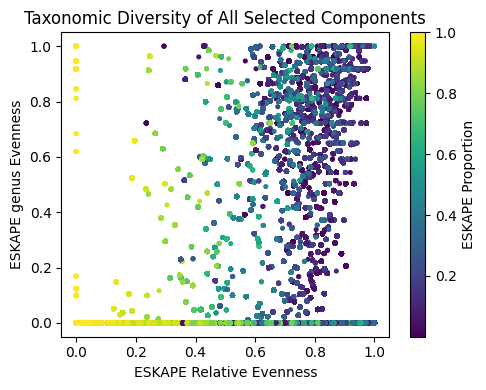

In [33]:
#make a scetter plot of taxonomic diversity for the all selected components

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))

scatter = ax.scatter(
    atlas_search_results_maped_with_componentID_selected['ESKAPE_relative_evenness'], 
    atlas_search_results_maped_with_componentID_selected['ESKAPE_genus_evenness'], 
    c=atlas_search_results_maped_with_componentID_selected['ESKAPE_proportion'], 
    cmap='viridis', 
    marker='o', 
    s=7)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('ESKAPE Proportion', fontsize=10) 

ax.set_title('Taxonomic Diversity of All Selected Components', fontsize=12) 
ax.set_xlabel('ESKAPE Relative Evenness', fontsize=10)    
ax.set_ylabel('ESKAPE genus Evenness', fontsize=10) 
ax.patch.set_alpha(0)

fig.tight_layout()

# Save the plot with a transparent background
fig.savefig('taxonomic_diversity_of_All_components.png', dpi=2000, transparent=True)

# Show the plot
plt.show()

In [34]:
# select queryIDs that were maped to dark components (median darkness <= 4%)
atlas_search_results_maped_with_componentID_selected_dark = atlas_search_results_maped_with_componentID_selected.loc[atlas_search_results_maped_with_componentID_selected['component_brightness'] <= 5]
atlas_search_results_maped_with_componentID_selected_dark

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
2006446,PALA23_RS25565,A0A367M2P5,0.954,110,5,0,55,164,3,112,3.428000e-65,224,133[1],0.0,133,0.0,0.795258,0.131107,0.058511
2006447,M2I93_RS28125,A0A367M2P5,0.963,110,4,0,55,164,3,112,7.077000e-66,226,133[1],0.0,133,0.0,0.795258,0.131107,0.058511
2006448,MKF35_RS10835,A0A367M2P5,0.963,110,4,0,55,164,3,112,7.077000e-66,226,133[1],0.0,133,0.0,0.795258,0.131107,0.058511
2006449,PALA4_RS27830,A0A367M2P5,0.945,110,6,0,55,164,3,112,4.699000e-65,223,133[1],0.0,133,0.0,0.795258,0.131107,0.058511
2006450,PALA36_RS28265,A0A367M2P5,0.945,110,6,0,55,164,3,112,4.699000e-65,223,133[1],0.0,133,0.0,0.795258,0.131107,0.058511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2691745,HV91_RS26755,Q5W380,0.822,124,22,0,1,124,1,124,2.897000e-56,210,240823[0],0.0,240823,0.0,1.000000,0.000000,0.333333
2691746,HUK75_RS26255,Q5W380,0.822,124,22,0,1,124,1,124,7.444000e-61,220,240823[0],0.0,240823,0.0,1.000000,0.000000,0.333333
2691747,CDL16_RS17765,Q5W380,0.824,125,22,0,1,125,1,125,6.633000e-68,229,240823[0],0.0,240823,0.0,1.000000,0.000000,0.333333
2691748,PA34_RS27525,Q5W380,0.822,124,22,0,1,124,1,124,7.444000e-61,220,240823[0],0.0,240823,0.0,1.000000,0.000000,0.333333


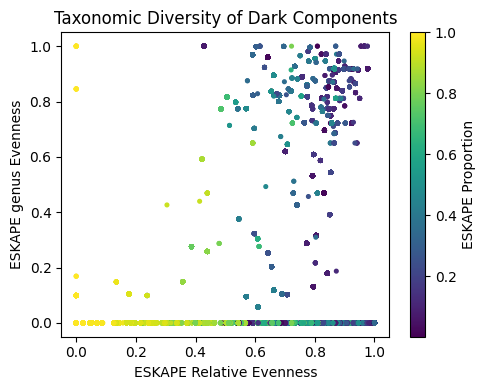

In [35]:
#make a scetter plot of taxonomic diversity only for dark maped components 

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))

scatter = ax.scatter(
    atlas_search_results_maped_with_componentID_selected_dark['ESKAPE_relative_evenness'], 
    atlas_search_results_maped_with_componentID_selected_dark['ESKAPE_genus_evenness'], 
    c=atlas_search_results_maped_with_componentID_selected_dark['ESKAPE_proportion'], 
    cmap='viridis', 
    marker='o', 
    s=7)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('ESKAPE Proportion', fontsize=10) 

ax.set_title('Taxonomic Diversity of Dark Components', fontsize=12) 
ax.set_xlabel('ESKAPE Relative Evenness', fontsize=10)      
ax.set_ylabel('ESKAPE genus Evenness', fontsize=10)
ax.patch.set_alpha(0)

fig.tight_layout()

fig.savefig('taxonomic_diversity_of_dark_components.png', dpi=2000, transparent=True)

plt.show()

In [36]:
# add sequences to each queryID in the atlas_search_results data frame


atlas_search_results = pd.read_csv('./ECLIPSE.csv', index_col='Unnamed: 0')
atlas_search_results

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
0,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0,97.44,0.632360,0.810699,0.069490
1,N5938_RS19225,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44,0,97.44,0.632360,0.810699,0.069490
2,O4M85_RS17570,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44,0,97.44,0.632360,0.810699,0.069490
3,RW109_RS21790,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44,0,97.44,0.632360,0.810699,0.069490
4,MMZ72_RS22095,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0,97.44,0.632360,0.810699,0.069490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2691751,P4N66_RS27185,P07684,0.987,406,5,0,1,406,1,406,4.001000e-258,794,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667
2691752,QAY87_RS29255,Q5BLX3,0.996,313,1,0,15,327,1,313,3.136000e-200,627,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667
2691753,Q7F19_RS33075,Q5BLX3,0.996,313,1,0,15,327,1,313,3.136000e-200,627,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667
2691754,JMX72_RS24810,P07684,0.987,406,5,0,1,406,1,406,4.001000e-258,794,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667


In [37]:
# Read all FASTA files and build:
#   (1) seq_df          -- queryID + SEQ table used downstream
#   (2) queryID_to_strain.csv -- universal protein->strain mapping for Part III S4 scoring
#
# Strain identity is extracted from the .faa FILENAME, not from the sequence ID.
# This is necessary because NCBI queryIDs (e.g. ABD20461.1) are protein accessions
# that contain no strain information. The filename is the only reliable source.
#
# Extraction priority (works for any ESKAPE pathogen):
#   1. GCF/GCA accession in filename  ->  GCF_000013425.1_ASM1342v1_protein.faa  ->  GCF_000013425.1
#   2. Full filename stem (no ext)    ->  PAO1.faa  ->  PAO1 / Ab307-0294.faa  ->  Ab307-0294

from Bio import SeqIO
import os, re

directory_path = './faa'

_accession_re = re.compile(r'(GC[FA]_\d+\.\d+)', re.IGNORECASE)

def strain_from_filename(fname):
    """Return a stable, unique strain ID from any NCBI or custom .faa filename."""
    m = _accession_re.search(fname)
    if m:
        return m.group(1)                      # e.g. GCF_000013425.1
    stem = fname
    for ext in ('.faa', '.fasta', '.fa', '.fna'):
        if stem.lower().endswith(ext):
            stem = stem[:-len(ext)]
            break
    return stem                                # e.g. PAO1, Ab307-0294, MRSA252

queryID      = []
seq          = []
strain_label = []   # one entry per protein -- carries strain identity through the pipeline

for fasta_file in os.listdir(directory_path):

    if fasta_file.startswith('.'):            # skip hidden files (.DS_Store etc.)
        continue
    fasta_file_path = os.path.join(directory_path, fasta_file)
    if not os.path.isfile(fasta_file_path):   # skip subdirectories
        continue

    strain = strain_from_filename(fasta_file)

    try:
        sequences = list(SeqIO.parse(fasta_file_path, "fasta"))
    except UnicodeDecodeError:
        with open(fasta_file_path, encoding="latin-1") as handle:
            sequences = list(SeqIO.parse(handle, "fasta"))

    for seq_record in sequences:
        queryID.append(seq_record.id)
        seq.append(str(seq_record.seq))
        strain_label.append(strain)

seq_df = pd.DataFrame({'queryID': queryID, 'SEQ': seq, 'strain': strain_label})

# Save the protein -> strain mapping for Part III (S4 strain coverage scoring)
strain_map = seq_df[['queryID', 'strain']].drop_duplicates()
strain_map.to_csv('./queryID_to_strain.csv', index=False)

print(f"Total proteins read : {len(seq_df):,}")
print(f"Unique strains found: {seq_df['strain'].nunique():,}")
print(f"Strain mapping saved: queryID_to_strain.csv")
print()
print("Sample (first 5 rows):")
print(seq_df[['queryID', 'strain']].head())
seq_df

Total proteins read : 3,908,421
Unique strains found: 635
Strain mapping saved: queryID_to_strain.csv

Sample (first 5 rows):
        queryID                           strain
0  Y880_RS00010  Pseudomonas_aeruginosa_PAK_6441
1  Y880_RS00015  Pseudomonas_aeruginosa_PAK_6441
2  Y880_RS00020  Pseudomonas_aeruginosa_PAK_6441
3  Y880_RS00025  Pseudomonas_aeruginosa_PAK_6441
4  Y880_RS00030  Pseudomonas_aeruginosa_PAK_6441


,queryID,SEQ,strain
0,Y880_RS00010,MAAWLVRMSAYAELHCLSNFSFQRGASSAAELFARAARLGYRALAI...,Pseudomonas_aeruginosa_PAK_6441
1,Y880_RS00015,MLWACILLPQLAMDSALRQRNNPDAPLALLGGPAQRRQLQAVNPAA...,Pseudomonas_aeruginosa_PAK_6441
2,Y880_RS00020,MWKGQSAVPAGASLPTGHARLDALLPGGGWPEHALNEILHARDGVG...,Pseudomonas_aeruginosa_PAK_6441
3,Y880_RS00025,MDTLAPESTRQNLRSQRLNLLTNEPHQRLESLVKSKEPFASRDNFA...,Pseudomonas_aeruginosa_PAK_6441
4,Y880_RS00030,MHRSSQVLPALILGLAMNATLADEPTPPANCINTEVNGYQALSYEC...,Pseudomonas_aeruginosa_PAK_6441
...,...,...,...
3908416,PAC13_RS35225,MAARITDDEWDELTPENFDTTALLRAVDAVDVLRGDLNDSADGAPP...,Pseudomonas_aeruginosa_C13_22800
3908417,PAC13_RS35230,MQKRIIEGVEVQRSSGNVFADLGLPDAEKLKIKTGLVVEIRRAMRA...,Pseudomonas_aeruginosa_C13_22800
3908418,PAC13_RS35235,MTNKEKPLEWIASSHKDLMALPSDVRRRFGYALSLAQIGDQDDAAK...,Pseudomonas_aeruginosa_C13_22800
3908419,PAC13_RS35240,MLVGYMRVSSDSDRQSTDLQRDALLAAGVDPRHLFEDRASGAKDDR...,Pseudomonas_aeruginosa_C13_22800


In [38]:
# Select only queryIDs that are in atlas_search_results, drop duplicates,
# sort by queryID. The strain column is preserved through this filter.

seq_df = seq_df.loc[seq_df['queryID'].isin(atlas_search_results['queryID'])]
seq_df = seq_df.drop_duplicates(subset='queryID')   # explicit subset preserves strain
seq_df.sort_values(by=['queryID'], inplace=True)

# Re-save queryID_to_strain.csv AFTER filtering to only matched queryIDs.
# This ensures the mapping contains exactly the proteins that will be analysed,
# avoiding unmapped-protein warnings in Part III.
strain_map_filtered = seq_df[['queryID', 'strain']].drop_duplicates()
strain_map_filtered.to_csv('./queryID_to_strain.csv', index=False)
print(f"queryID_to_strain.csv updated after atlas filter:")
print(f"  Proteins matched to atlas : {len(strain_map_filtered):,}")
print(f"  Unique strains retained   : {strain_map_filtered['strain'].nunique():,}")

seq_df

queryID_to_strain.csv updated after atlas filter:
  Proteins matched to atlas : 2,691,756
  Unique strains retained   : 635


,queryID,SEQ,strain
1330657,A0K_RS00005,MSVELWQQCVDLLRDELPSQQFNTWIRPLQVEAEGDELRVYAPNRF...,Pseudomonas_aeruginosa_PACS2_84
1326196,A0K_RS00015,MSLTRVSVTAVRNLHPVTLSPSPRINILYGDNGSGKTSVLEAIHLL...,Pseudomonas_aeruginosa_PACS2_84
1326197,A0K_RS00020,MSENNTYDSSSIKVLKGLDAVRKRPGMYIGDTDDGTGLHHMVFEVV...,Pseudomonas_aeruginosa_PACS2_84
1331773,A0K_RS00030,MSRSLLILDRDGVINLDSDDYIKTLDEWIPIPSSIEAIARLSQAGW...,Pseudomonas_aeruginosa_PACS2_84
1330658,A0K_RS00035,MKRLKKTLHLSSLSLASLALSSAALAAAPVMLDQGKEWTESHRQDF...,Pseudomonas_aeruginosa_PACS2_84
...,...,...,...
2873720,Ysp71_RS33380,MSAVTQHHADELARGADELGVALDADKQRQLLAYLALLIKWNKAYN...,Pseudomonas_aeruginosa_Y71_9532
2873721,Ysp71_RS33385,MDFPTRFDVIVIGGGHAGTEAALAAARMGVKTLLLTHNVETLGQMS...,Pseudomonas_aeruginosa_Y71_9532
2873724,Ysp71_RS33405,MQAATETIVAIATAQGRGGVGIVRISGPLAGQIAVAVSGRQLKARH...,Pseudomonas_aeruginosa_Y71_9532
2873725,Ysp71_RS33410,MDIQRSILIVALAVVSYLLVLQWNKDYGQPELPAASASMNTTQGLP...,Pseudomonas_aeruginosa_Y71_9532


In [39]:
# sort values in the atlas_seqrch_result by queryID

atlas_search_results.sort_values(by=['queryID'], inplace=True)
atlas_search_results

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
1640068,A0K_RS00005,A0A0A2W3F8,0.647,471,147,0,25,495,2,418,3.675000e-175,560,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
1656506,A0K_RS00015,A0A451EP17,0.605,360,142,0,1,360,1,360,9.077000e-146,467,0[70148],99.73,0,97.44,0.632360,0.810699,0.069490
1640100,A0K_RS00020,A0A0A2W3F8,0.675,799,259,0,8,806,1092,1890,0.000000e+00,1116,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
590232,A0K_RS00030,A0A4Q6F4N6,0.773,137,31,0,41,177,1,137,2.012000e-66,228,0[19063],99.28,0,97.44,0.632360,0.810699,0.069490
2080939,A0K_RS00035,A0A1W9GXS9,0.568,410,175,0,162,568,2,411,4.842000e-138,455,516[15],60.10,516,69.58,0.859917,0.000000,0.012848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1406917,Ysp71_RS33380,A0A2G2Q084,0.533,210,98,0,1,210,1,210,3.068000e-67,232,0[49693],98.63,0,97.44,0.632360,0.810699,0.069490
1626271,Ysp71_RS33385,Q6F9Q1,0.720,626,175,0,1,626,1,625,1.207000e-296,918,0[6765],99.85,0,97.44,0.632360,0.810699,0.069490
1975689,Ysp71_RS33405,A0A7C5CPU8,0.652,190,66,0,1,190,1,190,4.982000e-65,237,39[8],98.03,39,98.82,0.782502,0.626428,0.013778
1975790,Ysp71_RS33410,A0A3M4K3S9,0.757,409,94,0,170,578,1,388,2.099000e-201,640,39[17],98.97,39,98.82,0.782502,0.626428,0.013778


In [40]:
# Remove any queryIDs labeled 'LongLink' -- this can occur when MMseqs2 truncates
# a sequence name that exceeds its internal identifier length limit.
# Using a label-based filter instead of a hardcoded index makes this universal.

longlink_mask = atlas_search_results['queryID'] == 'LongLink'
n_longlink = longlink_mask.sum()
if n_longlink > 0:
    print(f"Dropping {n_longlink} row(s) where queryID == 'LongLink'")
    atlas_search_results = atlas_search_results.loc[~longlink_mask].reset_index(drop=True)
else:
    print("No LongLink entries found -- nothing dropped.")
atlas_search_results

No LongLink entries found -- nothing dropped.


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
1640068,A0K_RS00005,A0A0A2W3F8,0.647,471,147,0,25,495,2,418,3.675000e-175,560,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
1656506,A0K_RS00015,A0A451EP17,0.605,360,142,0,1,360,1,360,9.077000e-146,467,0[70148],99.73,0,97.44,0.632360,0.810699,0.069490
1640100,A0K_RS00020,A0A0A2W3F8,0.675,799,259,0,8,806,1092,1890,0.000000e+00,1116,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
590232,A0K_RS00030,A0A4Q6F4N6,0.773,137,31,0,41,177,1,137,2.012000e-66,228,0[19063],99.28,0,97.44,0.632360,0.810699,0.069490
2080939,A0K_RS00035,A0A1W9GXS9,0.568,410,175,0,162,568,2,411,4.842000e-138,455,516[15],60.10,516,69.58,0.859917,0.000000,0.012848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1406917,Ysp71_RS33380,A0A2G2Q084,0.533,210,98,0,1,210,1,210,3.068000e-67,232,0[49693],98.63,0,97.44,0.632360,0.810699,0.069490
1626271,Ysp71_RS33385,Q6F9Q1,0.720,626,175,0,1,626,1,625,1.207000e-296,918,0[6765],99.85,0,97.44,0.632360,0.810699,0.069490
1975689,Ysp71_RS33405,A0A7C5CPU8,0.652,190,66,0,1,190,1,190,4.982000e-65,237,39[8],98.03,39,98.82,0.782502,0.626428,0.013778
1975790,Ysp71_RS33410,A0A3M4K3S9,0.757,409,94,0,170,578,1,388,2.099000e-201,640,39[17],98.97,39,98.82,0.782502,0.626428,0.013778


In [41]:
# Merge sequences (and strain label) into atlas_search_results.
# The strain column from seq_df is carried into eclipse_seq.csv automatically,
# making it available for any downstream use alongside queryID_to_strain.csv.

atlas_search_results_with_seq = pd.merge(seq_df, atlas_search_results, on='queryID')
atlas_search_results_with_seq.to_csv('./eclipse_seq.csv')  # strain column included

# Confirm strain column is present
if 'strain' in atlas_search_results_with_seq.columns:
    print(f"strain column present in eclipse_seq.csv -")
    print(f"  Unique strains: {atlas_search_results_with_seq['strain'].nunique():,}")
else:
    print("WARNING: strain column missing from eclipse_seq.csv -- check seq_df")

atlas_search_results_with_seq

strain column present in eclipse_seq.csv -
  Unique strains: 635


,queryID,SEQ,strain,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,...,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
0,A0K_RS00005,MSVELWQQCVDLLRDELPSQQFNTWIRPLQVEAEGDELRVYAPNRF...,Pseudomonas_aeruginosa_PACS2_84,A0A0A2W3F8,0.647,471,147,0,25,495,...,418,3.675000e-175,560,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
1,A0K_RS00015,MSLTRVSVTAVRNLHPVTLSPSPRINILYGDNGSGKTSVLEAIHLL...,Pseudomonas_aeruginosa_PACS2_84,A0A451EP17,0.605,360,142,0,1,360,...,360,9.077000e-146,467,0[70148],99.73,0,97.44,0.632360,0.810699,0.069490
2,A0K_RS00020,MSENNTYDSSSIKVLKGLDAVRKRPGMYIGDTDDGTGLHHMVFEVV...,Pseudomonas_aeruginosa_PACS2_84,A0A0A2W3F8,0.675,799,259,0,8,806,...,1890,0.000000e+00,1116,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
3,A0K_RS00030,MSRSLLILDRDGVINLDSDDYIKTLDEWIPIPSSIEAIARLSQAGW...,Pseudomonas_aeruginosa_PACS2_84,A0A4Q6F4N6,0.773,137,31,0,41,177,...,137,2.012000e-66,228,0[19063],99.28,0,97.44,0.632360,0.810699,0.069490
4,A0K_RS00035,MKRLKKTLHLSSLSLASLALSSAALAAAPVMLDQGKEWTESHRQDF...,Pseudomonas_aeruginosa_PACS2_84,A0A1W9GXS9,0.568,410,175,0,162,568,...,411,4.842000e-138,455,516[15],60.10,516,69.58,0.859917,0.000000,0.012848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2691751,Ysp71_RS33380,MSAVTQHHADELARGADELGVALDADKQRQLLAYLALLIKWNKAYN...,Pseudomonas_aeruginosa_Y71_9532,A0A2G2Q084,0.533,210,98,0,1,210,...,210,3.068000e-67,232,0[49693],98.63,0,97.44,0.632360,0.810699,0.069490
2691752,Ysp71_RS33385,MDFPTRFDVIVIGGGHAGTEAALAAARMGVKTLLLTHNVETLGQMS...,Pseudomonas_aeruginosa_Y71_9532,Q6F9Q1,0.720,626,175,0,1,626,...,625,1.207000e-296,918,0[6765],99.85,0,97.44,0.632360,0.810699,0.069490
2691753,Ysp71_RS33405,MQAATETIVAIATAQGRGGVGIVRISGPLAGQIAVAVSGRQLKARH...,Pseudomonas_aeruginosa_Y71_9532,A0A7C5CPU8,0.652,190,66,0,1,190,...,190,4.982000e-65,237,39[8],98.03,39,98.82,0.782502,0.626428,0.013778
2691754,Ysp71_RS33410,MDIQRSILIVALAVVSYLLVLQWNKDYGQPELPAASASMNTTQGLP...,Pseudomonas_aeruginosa_Y71_9532,A0A3M4K3S9,0.757,409,94,0,170,578,...,388,2.099000e-201,640,39[17],98.97,39,98.82,0.782502,0.626428,0.013778


## 3. Part II — Two-Track Stratification

In [42]:
# load all the atlas data 
# it excludes anything uniparc

# NOTE: you need to modify the paths here for your system 

# MEMORY FIX: load only the columns used downstream instead of the full ~4 GB file.
usecols = ['UniRef50IDs', 'communityIDs', 'genus', 'species', 'brightness']

atlas_datafiles = ['AFDB90v4_cc_data_uniprot_community_taxonomy_map_with_brightness.csv',
                   'AFDB90v4_dust_uniprot_community_taxonomy_map_with_brightness.csv']

frames = []
for f in atlas_datafiles:
    print(f)
    label = f.split('AFDB90v4_')[-1].split('_')[0]
    df = pd.read_csv(f, sep=',', usecols=usecols)
    df['label'] = label
    frames.append(df)

atlas_data = pd.concat(frames, axis=0, ignore_index=True)
del frames  # release the per-file copies so peak memory stays low

# brightness -> float32 (harmless if already numeric); trims memory further
atlas_data['brightness'] = pd.to_numeric(atlas_data['brightness'], downcast='float')

# drop 'UniRef50_' in UniRef50ID names and add componentIDs
# (vectorized .str is lighter and faster than .apply over tens of millions of rows)
atlas_data['UniRef50IDs'] = atlas_data['UniRef50IDs'].str.split('_').str[1]
atlas_data['componentIDs'] = atlas_data['communityIDs'].str.split('[').str[0].astype('int64')

atlas_data

AFDB90v4_cc_data_uniprot_community_taxonomy_map_with_brightness.csv
AFDB90v4_dust_uniprot_community_taxonomy_map_with_brightness.csv


,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs
0,Corynebacterium,Corynebacterium amycolatum,E2MW64,1920284[0],96.680000,cc,1920284
1,Acinetobacter,Acinetobacter haemolyticus,N9TGA3,21487[0],99.089996,cc,21487
2,Acinetobacter,Acinetobacter genomosp. 16BJ,N9TGA3,21487[0],99.089996,cc,21487
3,Acinetobacter,Acinetobacter sp. ETR1,N8WWZ2,51933[0],86.730003,cc,51933
4,Acinetobacter,Acinetobacter guillouiae,N8WWZ2,51933[0],86.730003,cc,51933
...,...,...,...,...,...,...,...
38500629,Haptolina,Haptolina brevifila,A0A7S2D1G0,1612739[0],66.959999,dust,1612739
38500630,Bradyrhizobium,Bradyrhizobium sp. CCBAU 51765,A0A7S7T862,1627339[0],86.500000,dust,1627339
38500631,Clytia,Clytia hemisphaerica,A0A7M5WQ56,1597478[0],98.959999,dust,1597478
38500632,Clytia,Clytia hemisphaerica,A0A7M5WQ56,1597478[0],98.959999,dust,1597478


In [43]:
# ===========================================================================
# UNIVERSAL CONFIG -- change ONLY this block for each new pathogen
# ===========================================================================
GENUS        = "Pseudomonas"             # genus for genus-specific filter
SPECIES      = "Pseudomonas aeruginosa"  # species string in Atlas proportion
SPECIES_COL  = "p_aeruginosa_proportion" # column name used in all output CSVs
INPUT_CSV    = "eclipse_search_results_component_dark.csv" # Part I output file
PS_OUT_CSV   = "./mapped_p_aer_dataset_pseudomonas_specific_dark_components.csv"
ES_OUT_CSV   = "./mapped_p_aer_dataset_eskape_enriched_dark_components.csv"
# ===========================================================================

# Load queryIDs from dataset with mapped dark components
dataset = pd.read_csv(INPUT_CSV, index_col='Unnamed: 0')
print(f"Loaded: {len(dataset):,} rows, {dataset['componentID'].nunique():,} components")
print(f"Genus   : {GENUS}")
print(f"Species : {SPECIES}")
print(f"Col     : {SPECIES_COL}")
dataset

Loaded: 100,677 rows, 659 components
Genus   : Pseudomonas
Species : Pseudomonas aeruginosa
Col     : p_aeruginosa_proportion


,queryID,SEQ,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
42,A0K_RS00330,MRTLLLAGGLLVLSGCSLLMPTPDPNRAWVDLDTQPDADLAAVEVD...,A0A3Q8TXC2,0.594,138,55,0,1,138,1,137,2.580000e-51,182,19565[0],0.00,19565,0,0.000000,0.000000,1.000000
65,A0K_RS00505,MELLNATPLAAAYNQGLDAEGRESLVVIAKGSFDLPLDGREARLLD...,Q4KCC5,0.652,368,128,0,1,368,1,368,2.520000e-161,512,1098[0],0.00,1098,0,0.642737,0.252927,0.251058
230,A0K_RS01590,MRVTLPCLGLAALMFGASASLMAADLPRTKAPEGAKVYFITPADGA...,K9NT45,0.522,136,63,0,10,145,10,141,1.450000e-38,146,2928[1],0.00,2928,0,0.328237,0.000000,0.809524
245,A0K_RS01680,MEHFLQIKILHGVATVLLFGGLLGLAFYAWRSWRTGDAARVARGFK...,A6UYD4,0.961,155,6,0,1,155,1,155,2.240000e-92,301,236145[0],0.00,236145,0,0.000000,0.000000,1.000000
255,A0K_RS01750,MSHTTHPGLDALWLTEAVRLREEQAGPLEDSEAVRQALAQGGSLPR...,A0A101DAH3,0.672,235,76,0,1,234,1,235,3.340000e-79,279,122382[0],0.00,122382,0,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2691567,Ysp71_RS32085,MDLDRLYLSHWQFSEHHQRLIDAPAAAVLDAVEDLLRFDDPLVRAF...,A0A6B8M558,0.434,175,94,0,6,180,7,173,9.490000e-35,137,5959[2],0.00,5959,0,0.962961,0.000000,0.285714
2691652,Ysp71_RS32645,MRRFPFARLLLLALLSSPLVHAELPETDWLELMPPADRKALEEMPD...,A0A7X6W798,0.587,97,40,0,79,175,2,98,1.780000e-34,136,17143[0],0.00,17143,0,0.960964,0.000000,0.200000
2691668,Ysp71_RS32755,MRSKPLLPALLLVGAGLSPLAQASSDDSCYPDWSLVGGGVCDTLPF...,A0A3M5DA23,0.994,502,3,0,1,502,1,502,0.000000e+00,990,26724[0],95.83,26724,0,0.723308,0.000000,0.666667
2691728,Ysp71_RS33230,MSALPQEKPLPCQAFDDDPQVLAEVLREGVNLAVWTRRLSPALRDF...,A0A1H7FFH0,0.548,213,96,0,1,213,1,213,1.980000e-63,221,1885[9],0.00,1885,0,0.724190,0.000000,0.073684


In [44]:
# Add the proportion of target species proteins to each component in dataset
# Uses SPECIES and SPECIES_COL from config -- no hardcoding needed

all_selected_dark_components = dataset['componentID'].unique().tolist()
atlas_data_selected = atlas_data.loc[atlas_data['componentIDs'].isin(all_selected_dark_components)]

# Calculate proportion of target species per componentID
props = atlas_data_selected.groupby('componentIDs')['species'].transform(
    lambda x: x.str.contains(SPECIES, regex=False).sum() / len(x))

# Create a new DataFrame with unique componentIDs and their corresponding proportion
components_with_prob = atlas_data_selected[['componentIDs']].copy()
components_with_prob.rename(columns={'componentIDs': 'componentID'}, inplace=True)
components_with_prob[SPECIES_COL] = props

# Drop duplicates to keep one row per componentID
components_with_prob = components_with_prob.drop_duplicates().reset_index(drop=True)

# Merge into dataset
dataset = dataset.merge(components_with_prob, on='componentID', how='left')
dataset

,queryID,SEQ,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,...,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion,p_aeruginosa_proportion
0,A0K_RS00330,MRTLLLAGGLLVLSGCSLLMPTPDPNRAWVDLDTQPDADLAAVEVD...,A0A3Q8TXC2,0.594,138,55,0,1,138,1,...,2.580000e-51,182,19565[0],0.00,19565,0,0.000000,0.000000,1.000000,0.000000
1,A0K_RS00505,MELLNATPLAAAYNQGLDAEGRESLVVIAKGSFDLPLDGREARLLD...,Q4KCC5,0.652,368,128,0,1,368,1,...,2.520000e-161,512,1098[0],0.00,1098,0,0.642737,0.252927,0.251058,0.001284
2,A0K_RS01590,MRVTLPCLGLAALMFGASASLMAADLPRTKAPEGAKVYFITPADGA...,K9NT45,0.522,136,63,0,10,145,10,...,1.450000e-38,146,2928[1],0.00,2928,0,0.328237,0.000000,0.809524,0.000000
3,A0K_RS01680,MEHFLQIKILHGVATVLLFGGLLGLAFYAWRSWRTGDAARVARGFK...,A6UYD4,0.961,155,6,0,1,155,1,...,2.240000e-92,301,236145[0],0.00,236145,0,0.000000,0.000000,1.000000,0.363636
4,A0K_RS01750,MSHTTHPGLDALWLTEAVRLREEQAGPLEDSEAVRQALAQGGSLPR...,A0A101DAH3,0.672,235,76,0,1,234,1,...,3.340000e-79,279,122382[0],0.00,122382,0,0.000000,0.000000,1.000000,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100672,Ysp71_RS32085,MDLDRLYLSHWQFSEHHQRLIDAPAAAVLDAVEDLLRFDDPLVRAF...,A0A6B8M558,0.434,175,94,0,6,180,7,...,9.490000e-35,137,5959[2],0.00,5959,0,0.962961,0.000000,0.285714,0.000000
100673,Ysp71_RS32645,MRRFPFARLLLLALLSSPLVHAELPETDWLELMPPADRKALEEMPD...,A0A7X6W798,0.587,97,40,0,79,175,2,...,1.780000e-34,136,17143[0],0.00,17143,0,0.960964,0.000000,0.200000,0.000000
100674,Ysp71_RS32755,MRSKPLLPALLLVGAGLSPLAQASSDDSCYPDWSLVGGGVCDTLPF...,A0A3M5DA23,0.994,502,3,0,1,502,1,...,0.000000e+00,990,26724[0],95.83,26724,0,0.723308,0.000000,0.666667,0.111111
100675,Ysp71_RS33230,MSALPQEKPLPCQAFDDDPQVLAEVLREGVNLAVWTRRLSPALRDF...,A0A1H7FFH0,0.548,213,96,0,1,213,1,...,1.980000e-63,221,1885[9],0.00,1885,0,0.724190,0.000000,0.073684,0.000000


In [45]:
# Extract solely ESKAPE-specific components (ESKAPE_proportion == 1.0)

eskape_specific_components = dataset.loc[
    dataset["ESKAPE_proportion"] == 1.0, "componentID"
].unique().tolist()

print(f"ESKAPE-specific components (proportion == 1.0): {len(eskape_specific_components)}")

ESKAPE-specific components (proportion == 1.0): 109


In [46]:
# Filter for components that contain proteins ONLY from the target genus (GENUS from config)
# Step 1 -- re-derive ESKAPE-specific components from query dataset to be safe
eskape_specific_components = dataset.loc[
    dataset["ESKAPE_proportion"] == 1.0, "componentID"
].unique().tolist()
print(f"ESKAPE-specific components (proportion == 1.0): {len(eskape_specific_components)}")

# Step 2 -- from those, keep only components where ALL Atlas proteins are from GENUS
selected_atlas_data = atlas_data.loc[atlas_data["componentIDs"].isin(eskape_specific_components)]

genus_specific_components = selected_atlas_data.groupby("componentIDs").filter(
    lambda x: (x["genus"] == GENUS).all())

# Get unique componentIDs satisfying both conditions
component_ids_genus_specific = genus_specific_components["componentIDs"].unique().tolist()

# Select rows from dataset mapped to genus-specific components
dataset_genus_specific = dataset.loc[
    dataset["componentID"].isin(component_ids_genus_specific)
]

# Sanity check -- every genus-specific component must have ESKAPE_proportion == 1.0
bad = dataset_genus_specific.loc[
    dataset_genus_specific["ESKAPE_proportion"] < 1.0, "componentID"
].nunique()
if bad > 0:
    print(f"WARNING: {bad} components have ESKAPE_proportion < 1.0 -- check filter")
else:
    print("Sanity check PASSED -- all genus-specific components have ESKAPE_proportion == 1.0")

# Save output
dataset_genus_specific.to_csv(PS_OUT_CSV, index=False)
print(f"{GENUS}-specific components found: {len(component_ids_genus_specific)}")
print(f"Saved: {PS_OUT_CSV}")

ESKAPE-specific components (proportion == 1.0): 109
Sanity check PASSED -- all genus-specific components have ESKAPE_proportion == 1.0
Pseudomonas-specific components found: 83
Saved: ./mapped_p_aer_dataset_pseudomonas_specific_dark_components.csv


In [47]:
# View genus-specific components
dataset_genus_specific

,queryID,SEQ,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,...,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion,p_aeruginosa_proportion
3,A0K_RS01680,MEHFLQIKILHGVATVLLFGGLLGLAFYAWRSWRTGDAARVARGFK...,A6UYD4,0.961,155,6,0,1,155,1,...,2.240000e-92,301,236145[0],0.0,236145,0,0.0,0.0,1.0,0.363636
10,A0K_RS03160,MTRLLLGLCLLFAGCAASPTTPRPVRVEVPLAVPCRVPDVRPPSWA...,I3V1V2,0.622,61,23,0,25,85,4,...,1.370000e-14,74,33561[0],0.0,33561,0,0.0,0.0,1.0,0.250000
16,A0K_RS04455,MILGLCLTAMAGLLGYQQYQLIQLRSGVDSAAEKTSLEAILARLNR...,A0A3M5R050,0.671,70,23,0,153,222,2,...,1.360000e-22,103,194266[0],0.0,194266,0,0.0,0.0,1.0,0.000000
17,A0K_RS04520,MHMNAQTQPAALAAFPLNINLTDFIDEFGDELLESLNRSNPPVYTG...,A0A3M5K3K1,0.813,134,25,0,497,630,1,...,2.100000e-60,232,194257[0],0.0,194257,0,0.0,0.0,1.0,0.000000
18,A0K_RS04535,MNPLFTNLTQETLAYLEDQLSNNDVAGDDELIDLFIEELSLTLEQA...,A0A080VAE3,0.941,86,5,0,1,84,1,...,1.810000e-44,159,61895[0],0.0,61895,0,0.0,0.0,1.0,0.290323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100660,Ysp71_RS29860,MTRPTSVKPDNFFLLLFRALRQRRVPIALRLASHSLILVALALLIY...,A0A3D3MBK5,0.755,196,48,0,314,509,6,...,5.330000e-84,295,191318[0],0.0,191318,0,0.0,0.0,1.0,0.000000
100664,Ysp71_RS30585,MIDTPVVAALDMYVEPDCVRQAGATFIGEVCRRLGVRRYASAATDL...,A0A081HRD9,1.000,265,0,0,1,265,1,...,9.110000e-175,545,103202[0],0.0,103202,0,0.0,0.0,1.0,0.921053
100665,Ysp71_RS30695,MRLITSCLLLAAALPAMAQIYQYTDANGNKVFTNQPPDGVQAQTVE...,A0A7Z6XVD9,0.563,71,31,0,101,171,1,...,8.610000e-17,84,232744[0],0.0,232744,0,0.0,0.0,1.0,0.000000
100666,Ysp71_RS30800,MARAKSKTPILQLDAAQTQDAVLAIKRFMEDRFELELGSFEAEELL...,A0A367M4A4,1.000,51,0,0,36,86,7,...,9.220000e-25,103,184475[0],0.0,184475,0,0.0,0.0,1.0,0.333333


In [48]:
# Count genus-specific components that have zero proteins annotated as target species
# NOTE: this can happen due to non-canonical species naming in UniProt
# (e.g. "Pseudomonas sp." instead of "Pseudomonas aeruginosa")

components_zero_species = dataset_genus_specific["componentID"].loc[
    dataset_genus_specific[SPECIES_COL] == 0
].unique().tolist()

num = len(components_zero_species)
print(f"Found {num} {GENUS}-specific components with no proteins annotated as {SPECIES}")
print(f"(This is expected due to non-canonical species naming in UniProt)")

Found 57 Pseudomonas-specific components with no proteins annotated as Pseudomonas aeruginosa
(This is expected due to non-canonical species naming in UniProt)


In [49]:
# Inspect the taxonomic content of any component
# Replace the componentID below with any ID from components_zero_species or any other

atlas_data.loc[atlas_data["componentIDs"] == 194266]  # replace 194266 with any componentID

,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs
9361602,Pseudomonas,Pseudomonas syringae group genomosp. 3,A0A3M5R050,194266[0],0.0,cc,194266
25205454,Pseudomonas,Pseudomonas syringae,F3FN25,194266[0],0.0,cc,194266


In [50]:
# Select dark components with ESKAPE_proportion >= 0.5
# and exclude genus-specific components already selected in Part I

dataset_eskape_enriched = dataset.loc[
    (dataset["ESKAPE_proportion"] >= 0.5) &
    (~dataset["componentID"].isin(dataset_genus_specific["componentID"]))
]

# Save output
dataset_eskape_enriched.to_csv(ES_OUT_CSV, index=False)
print(f"ESKAPE-enriched components: {dataset_eskape_enriched['componentID'].nunique():,}")
print(f"Saved: {ES_OUT_CSV}")
dataset_eskape_enriched

ESKAPE-enriched components: 215
Saved: ./mapped_p_aer_dataset_eskape_enriched_dark_components.csv


,queryID,SEQ,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,...,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion,p_aeruginosa_proportion
0,A0K_RS00330,MRTLLLAGGLLVLSGCSLLMPTPDPNRAWVDLDTQPDADLAAVEVD...,A0A3Q8TXC2,0.594,138,55,0,1,138,1,...,2.580000e-51,182,19565[0],0.00,19565,0,0.000000,0.0,1.000000,0.000000
2,A0K_RS01590,MRVTLPCLGLAALMFGASASLMAADLPRTKAPEGAKVYFITPADGA...,K9NT45,0.522,136,63,0,10,145,10,...,1.450000e-38,146,2928[1],0.00,2928,0,0.328237,0.0,0.809524,0.000000
4,A0K_RS01750,MSHTTHPGLDALWLTEAVRLREEQAGPLEDSEAVRQALAQGGSLPR...,A0A101DAH3,0.672,235,76,0,1,234,1,...,3.340000e-79,279,122382[0],0.00,122382,0,0.000000,0.0,1.000000,0.166667
7,A0K_RS02490,MGTEGFFDGLGEMLGRAIRFVVDLLSGLLGGIWGAMDDFLHGLARA...,A0A1B3E0A5,0.666,96,32,0,1,96,1,...,1.300000e-33,129,129246[0],0.00,129246,0,0.875000,0.0,0.500000,0.000000
8,A0K_RS02890,MIPFGLSPEQFRERYRRDLQRAAPGVIQHLRELLRQPLEEGLRDGE...,A0A2U2Y4H7,0.993,156,1,0,1,156,1,...,1.190000e-105,340,175300[0],0.00,175300,0,0.399737,0.0,0.796875,0.611940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100662,Ysp71_RS30025,MPRMLARKDPSAFKTLPLLVEASPDGLVYQALGLPLNFQQMLVRRR...,A0A3N4AX60,0.517,288,138,0,1,286,1,...,3.150000e-85,289,116435[0],0.00,116435,0,0.566510,0.0,0.866667,0.000000
100663,Ysp71_RS30065,MKVLFLVQKEQRAILDRLYDGIAAHCECDTRWLSSEEQADLRGYFR...,A6DL43,0.498,303,151,0,1,301,14,...,1.470000e-88,299,19937[1],0.00,19937,0,0.133825,0.0,0.933007,0.041734
100667,Ysp71_RS30935,MSSRKKSPDLALVGEPKTPKPDKLERPCFAVYDEDTRVEGKTFRAG...,A0A3D2M925,0.422,391,222,0,186,576,2,...,1.040000e-75,274,21378[0],74.21,21378,0,0.832249,0.0,0.571429,0.000000
100670,Ysp71_RS31545,MAFTPELIDELELLALFNLNNTQEGLKVHHTADGKAVAAARRLHDK...,A0A418YDG7,0.424,73,41,0,4,76,8,...,3.370000e-14,72,89148[0],0.00,89148,0,1.000000,0.0,0.500000,0.000000


In [51]:
# View species proportion distribution in ESKAPE-enriched components

pd.options.display.max_rows = 300
dataset_eskape_enriched.groupby("componentID")[SPECIES_COL].value_counts()

componentID  p_aeruginosa_proportion
1717         0.003030                     16
1903         0.047109                    608
2572         0.050498                   1306
2722         0.000000                    501
2928         0.000000                    619
3713         0.008791                    626
7110         0.075862                    631
7682         0.016077                    635
8060         0.013158                     28
9665         0.000000                     86
10225        0.060729                    598
10282        0.021277                      4
11254        0.000000                      2
11264        0.209677                    191
11533        0.439024                    158
11859        0.215116                    636
12634        0.181818                     23
13272        0.000000                    632
13483        0.000000                      2
14191        0.051282                      5
14990        0.048780                     39
16870        0.000

In [52]:
# Closer look at ESKAPE-enriched components

df = dataset_eskape_enriched.drop_duplicates(subset=["componentID"], keep="first")
columns_to_drop = ["queryID", "SEQ", "targetID", "fident", "alnlen", "mismatch",
                   "gapopen", "qstart", "qend", "tstart", "tend", "eVal", "bits",
                   "communityID", "brightness"]
df = df.drop(columns=[c for c in columns_to_drop if c in df.columns])

# How many enriched with target species proteins?
num = df.loc[df[SPECIES_COL] >= 0.5, "componentID"].nunique()
print(f"Components with {SPECIES_COL} >= 0.5: {num}")

# How many specific to another ESKAPE genus (not the target genus)?
comp = df.loc[df["ESKAPE_genus_evenness"] == 0.0, "componentID"].tolist()
selected_atlas_data = atlas_data.loc[atlas_data["componentIDs"].isin(comp)]
filtered_components = selected_atlas_data.groupby("componentIDs").filter(
    lambda x: (x["genus"] != GENUS).all())
num2 = len(filtered_components["componentIDs"].unique().tolist())
print(f"Components specific to another ESKAPE genus (not {GENUS}): {num2}")

df

Components with p_aeruginosa_proportion >= 0.5: 16
Components specific to another ESKAPE genus (not Pseudomonas): 9


,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion,p_aeruginosa_proportion
0,19565,0,0.000000,0.000000,1.000000,0.000000
2,2928,0,0.328237,0.000000,0.809524,0.000000
4,122382,0,0.000000,0.000000,1.000000,0.166667
7,129246,0,0.875000,0.000000,0.500000,0.000000
8,175300,0,0.399737,0.000000,0.796875,0.611940
11,2722,0,0.505672,0.817345,0.684932,0.000000
12,142980,0,0.721928,0.000000,0.800000,0.000000
13,36974,0,0.520033,0.000000,0.745342,0.077381
14,89509,0,0.864974,0.918296,0.600000,0.000000
15,44616,0,0.069054,0.000000,0.991736,0.094650


## 4. Part III — DPPS Scoring & Sensitivity Analysis

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import subprocess
import math
import os
import re
import warnings
warnings.filterwarnings('ignore')

# ==========================================================================
# UNIVERSAL PATHOGEN CONFIG - change only this block for each new pathogen
# ==========================================================================
GENUS        = "Pseudomonas"           # genus used in Part II genus-specific filter
SPECIES      = "Pseudomonas aeruginosa"# species string used in Atlas proportion column
SPECIES_COL  = "p_aeruginosa_proportion" # column name as it appears in Part II CSVs
SPECIES_ABBR = "PA"                    # short label for plot axes and print statements
FAA_DIR      = "./faa"                 # folder of downloaded .faa files (for N_STRAINS)

#  Input files (Part II outputs) - filenames unchanged
PS_CSV = './mapped_p_aer_dataset_pseudomonas_specific_dark_components.csv'
ES_CSV = './mapped_p_aer_dataset_eskape_enriched_dark_components.csv'
# ==========================================================================

#  Filtering
MIN_SEQ_LEN = 300

# Auto-count strains from your downloaded .faa directory
# Each unique GCF/GCA accession = one strain. Falls back to filename stem.
_accession_re = re.compile(r'(GC[FA]_\d+\.\d+)', re.IGNORECASE)

def _strain_from_filename(fname):
    m = _accession_re.search(fname)
    if m:
        return m.group(1)
    for ext in ('.faa', '.fasta', '.fa', '.fna'):
        if fname.lower().endswith(ext):
            fname = fname[:-len(ext)]
            break
    return fname

def count_strains(faa_dir):
    if not os.path.isdir(faa_dir):
        raise FileNotFoundError(
            f"FAA directory not found: {faa_dir}\n"
            "Set FAA_DIR to your folder of downloaded .faa files."
        )
    files = [f for f in os.listdir(faa_dir)
             if os.path.isfile(os.path.join(faa_dir, f))
             and f.lower().endswith(('.faa', '.fasta', '.fa', '.fna'))
             and not f.startswith('.')]
    strains = {_strain_from_filename(f) for f in files}
    print(f"FAA directory    : {faa_dir}")
    print(f"Total .faa files : {len(files)}")
    print(f"Unique strains   : {len(strains)}")
    if len(files) != len(strains):
        print(f"  NOTE: file count differs from strain count")
        print(f"  (multi-file assemblies detected - using strain count)")
    return len(strains)

N_STRAINS = count_strains(FAA_DIR)

#  MMseqs2 clustering parameters
MMSEQS_MIN_SEQ_ID = 0.3
MMSEQS_COVERAGE   = 0.8
MMSEQS_TMP        = './tmp_mmseqs'

#  DPPS weights - genus-specific track (Track A)
# S2b replaces S2 for Track A.
# Genus-specific components can show suppressed Atlas species proportion due to
# non-canonical annotation in UniProt (e.g. 'Pseudomonas sp.').
# S2b = max(Atlas species proportion, query strain fraction) corrects for this.
WEIGHTS_PS = {
    'S1_darkness':           0.15,
    'S2b_pa_combined':       0.40,
    'S3_specificity':        0.25,
    'S4_pa_strain_coverage': 0.20,
}
assert abs(sum(WEIGHTS_PS.values()) - 1.0) < 1e-9, 'WEIGHTS_PS must sum to 1.0'

# DPPS weights - ESKAPE-enriched track (Track B)
# Track B uses standard S2 (Atlas species proportion) because ESKAPE-enriched
# components span multiple genera and Atlas annotation is more reliable
# at the ESKAPE level than at the species level.
WEIGHTS_ES = {
    'S1_darkness':           0.15,
    'S2_pa_proportion':      0.25,
    'S3_specificity':        0.20,
    'S4_pa_strain_coverage': 0.15,
    'S5_eskape_enrich':      0.25,
}
assert abs(sum(WEIGHTS_ES.values()) - 1.0) < 1e-9, 'WEIGHTS_ES must sum to 1.0'

# Tier boundaries
TIER_BINS   = [0, 0.25, 0.50, 0.75, 1.01]
TIER_LABELS = ['IV', 'III', 'II', 'I']
TIER_COLORS = {'I': '#7B2D8B', 'II': '#D85A30', 'III': '#1D9E75', 'IV': '#888780'}

os.makedirs(MMSEQS_TMP, exist_ok=True)
print()
print('Configuration loaded.')
print(f'  Genus            : {GENUS}')
print(f'  Species          : {SPECIES}')
print(f'  Species column   : {SPECIES_COL}')
print(f'  Genus-specific input : {PS_CSV}')
print(f'  ESKAPE-enriched input: {ES_CSV}')
print(f'  Min sequence length  : {MIN_SEQ_LEN} aa')
print(f'  Total strains        : {N_STRAINS}')
print(f'  MMseqs2: min-seq-id={MMSEQS_MIN_SEQ_ID}, coverage={MMSEQS_COVERAGE}')
print()
print('Track A weights (S2b = combined species evidence):')
for k, v in WEIGHTS_PS.items():
    print(f'  {k}: {v}')
print('Track B weights:')
for k, v in WEIGHTS_ES.items():
    print(f'  {k}: {v}')


FAA directory    : ./faa
Total .faa files : 635
Unique strains   : 635

Configuration loaded.
  Genus            : Pseudomonas
  Species          : Pseudomonas aeruginosa
  Species column   : p_aeruginosa_proportion
  Genus-specific input : ./mapped_p_aer_dataset_pseudomonas_specific_dark_components.csv
  ESKAPE-enriched input: ./mapped_p_aer_dataset_eskape_enriched_dark_components.csv
  Min sequence length  : 300 aa
  Total strains        : 635
  MMseqs2: min-seq-id=0.3, coverage=0.8

Track A weights (S2b = combined species evidence):
  S1_darkness: 0.15
  S2b_pa_combined: 0.4
  S3_specificity: 0.25
  S4_pa_strain_coverage: 0.2
Track B weights:
  S1_darkness: 0.15
  S2_pa_proportion: 0.25
  S3_specificity: 0.2
  S4_pa_strain_coverage: 0.15
  S5_eskape_enrich: 0.25


In [54]:
df_ps = pd.read_csv(PS_CSV)
df_es = pd.read_csv(ES_CSV)

print(f'Genus-specific  : {len(df_ps):,} proteins, '
      f'{df_ps["componentID"].nunique():,} components')
print(f'ESKAPE-enriched : {len(df_es):,} proteins, '
      f'{df_es["componentID"].nunique():,} components')
print(f'\nColumns: {list(df_ps.columns)}')


Genus-specific  : 13,230 proteins, 83 components
ESKAPE-enriched : 39,452 proteins, 215 components

Columns: ['queryID', 'SEQ', 'targetID', 'fident', 'alnlen', 'mismatch', 'gapopen', 'qstart', 'qend', 'tstart', 'tend', 'eVal', 'bits', 'communityID', 'brightness', 'componentID', 'component_brightness', 'ESKAPE_relative_evenness', 'ESKAPE_genus_evenness', 'ESKAPE_proportion', 'p_aeruginosa_proportion']


Pseudomonas-specific:
  Before: 13,230 proteins, 83 components
  Dropped: 70 components (median seq len < 300 aa)
  Dropped: 11,759 proteins from those components
  Retained: 1,471 proteins, 13 components
  Dropped component median lengths:
 componentID  median_seq_len
      107877            46.0
       51064            65.0
      168893            65.0
      158399            65.5
       79969            67.0
      129813            75.0
      118183            80.0
       61895            84.0
       33561            85.0
      184475            86.0
      194242            88.0
       92485            89.0
       23464            91.0
      118432            92.0
      130808            92.0
       67756            99.0
      123371           107.0
      112954           107.0
      114039           112.0
      132142           112.0
      159458           115.0
       67761           117.0
      109482           117.0
      115331           118.0
      148005           118.0
     

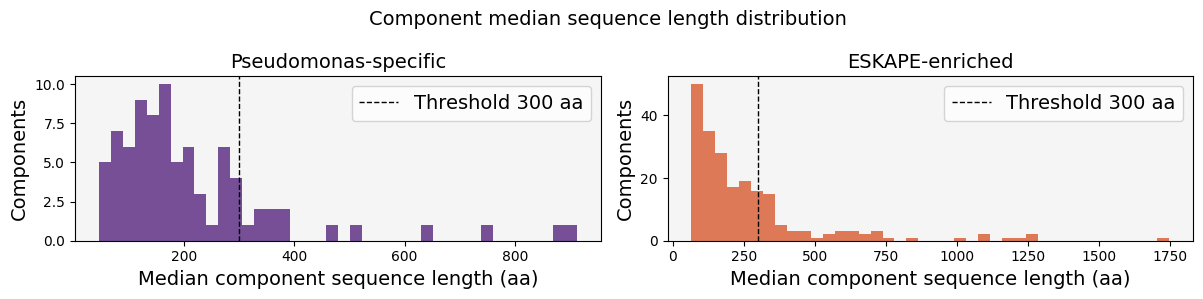

Saved: seq_len_both_tracks.pdf


In [55]:
def apply_length_filter(df_in, track_name, min_len=MIN_SEQ_LEN):
    """
    Filter by MEDIAN component sequence length, not individual protein length.
    This correctly handles components like 103202 where 623/626 proteins are
    265 aa but 3 outlier proteins are 304-340 aa - the component should be
    excluded based on its representative (median) length, not the outliers.
    """
    df_out = df_in.copy()
    df_out['seq_len'] = df_out['SEQ'].str.len()

    # Compute median sequence length per component
    comp_median_len = (
        df_out.groupby('componentID')['seq_len']
        .median()
        .reset_index(name='median_seq_len')
    )

    # Identify components where median length >= threshold
    valid_comps = comp_median_len.loc[
        comp_median_len['median_seq_len'] >= min_len, 'componentID'
    ].tolist()

    n_comps_before = df_out['componentID'].nunique()
    n_prots_before = len(df_out)

    # Keep ALL proteins from valid components
    df_out = df_out[df_out['componentID'].isin(valid_comps)].copy()

    n_comps_dropped = n_comps_before - df_out['componentID'].nunique()
    n_prots_dropped = n_prots_before - len(df_out)

    print(f'{track_name}:')
    print(f'  Before: {n_prots_before:,} proteins, {n_comps_before:,} components')
    print(f'  Dropped: {n_comps_dropped:,} components (median seq len < {min_len} aa)')
    print(f'  Dropped: {n_prots_dropped:,} proteins from those components')
    print(f'  Retained: {len(df_out):,} proteins, '
          f'{df_out["componentID"].nunique():,} components')

    # Show dropped components and their median lengths for transparency
    dropped = comp_median_len[~comp_median_len['componentID'].isin(valid_comps)]
    if len(dropped) > 0:
        print(f'  Dropped component median lengths:')
        print(dropped.sort_values('median_seq_len').to_string(index=False))

    return df_out

df_ps_filt = apply_length_filter(df_ps, f'{GENUS}-specific')
print()
df_es_filt = apply_length_filter(df_es, 'ESKAPE-enriched')

# Length distribution plots - show median seq len per component
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, df_in, title, color in zip(
        axes,
        [df_ps, df_es],
        [f'{GENUS}-specific', 'ESKAPE-enriched'],
        ['#57257F', '#D85A30']):
    df_in = df_in.copy()
    df_in['seq_len'] = df_in['SEQ'].str.len()
    median_lens = df_in.groupby('componentID')['seq_len'].median()
    ax.hist(median_lens, bins=40, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(MIN_SEQ_LEN, color='black', linewidth=1, linestyle='--',
               label=f'Threshold {MIN_SEQ_LEN} aa')
    ax.set_xlabel('Median component sequence length (aa)', fontsize=14)
    ax.set_ylabel('Components', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=14)
    ax.set_facecolor('#F5F5F5')
fig.suptitle('Component median sequence length distribution', fontsize=14)
fig.tight_layout()
plt.savefig('./seq_len_both_tracks.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: seq_len_both_tracks.pdf')


In [56]:
def write_fasta(df_in, fasta_path):
    df_unique = df_in.drop_duplicates(subset='queryID')
    with open(fasta_path, 'w') as fh:
        for _, row in df_unique.iterrows():
            fh.write(f'>{row["queryID"]}\n{row["SEQ"]}\n')
    print(f'Written {len(df_unique):,} sequences -> {fasta_path}')

write_fasta(df_ps_filt, './track_ps_pseudomonas_specific.fasta')
write_fasta(df_es_filt, './track_es_eskape_enriched.fasta')

Written 1,471 sequences -> ./track_ps_pseudomonas_specific.fasta
Written 15,078 sequences -> ./track_es_eskape_enriched.fasta


In [57]:
def run_mmseqs_cluster(fasta_in, prefix, tmp_dir, min_seq_id, coverage):
    cluster_tsv = f'{prefix}_cluster.tsv'
    if MMSEQS_BIN is None:
        raise RuntimeError(
            'MMseqs2 not found on PATH. See the bootstrap cell output for\n'
            'installation instructions (conda/brew on Linux+macOS; WSL2 on Windows).'
        )
    cmd = [
        MMSEQS_BIN, 'easy-cluster',
        fasta_in, prefix, tmp_dir,
        '--min-seq-id', str(min_seq_id),
        '-c',           str(coverage),
        '--cov-mode',   '0',
        '-v',           '1'
    ]
    print(f'Running: {" ".join(cmd)}')
    # text=True + explicit encoding keeps stdout decoding identical on Windows
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE,
                            text=True, encoding='utf-8', errors='replace')
    if result.returncode != 0:
        print('MMseqs2 stderr:')
        print(result.stderr[-1000:])
        return None
    print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
    return cluster_tsv

tsv_ps = run_mmseqs_cluster(
    './track_ps_pseudomonas_specific.fasta',
    './cluster_ps', MMSEQS_TMP, MMSEQS_MIN_SEQ_ID, MMSEQS_COVERAGE
)
print()
tsv_es = run_mmseqs_cluster(
    './track_es_eskape_enriched.fasta',
    './cluster_es', MMSEQS_TMP, MMSEQS_MIN_SEQ_ID, MMSEQS_COVERAGE
)

Running: /opt/homebrew/bin/mmseqs easy-cluster ./track_ps_pseudomonas_specific.fasta ./cluster_ps ./tmp_mmseqs --min-seq-id 0.3 -c 0.8 --cov-mode 0 -v 1


Running: /opt/homebrew/bin/mmseqs easy-cluster ./track_es_eskape_enriched.fasta ./cluster_es ./tmp_mmseqs --min-seq-id 0.3 -c 0.8 --cov-mode 0 -v 1



In [58]:
def parse_clusters(cluster_tsv, df_filtered, track_name):
    """
    Parse MMseqs2 cluster TSV (col0=representative, col1=member).
    Returns dataframe of representative proteins with cluster_size column.
    """
    clusters = pd.read_csv(cluster_tsv, sep='\t', header=None,
                           names=['representative', 'member'])

    # Count members per representative = cluster size
    cluster_sizes = (
        clusters.groupby('representative')
        .size()
        .reset_index(name='cluster_size')
    )

    # Select representative rows from filtered protein table
    reps = df_filtered.loc[
        df_filtered['queryID'].isin(cluster_sizes['representative'])
    ].drop_duplicates(subset='queryID').copy()

    reps = reps.merge(
        cluster_sizes, left_on='queryID', right_on='representative', how='left'
    )
    reps['cluster_size'] = reps['cluster_size'].fillna(1).astype(int)

    print(f'{track_name}:')
    print(f'  Proteins after length filter: {len(df_filtered):,}')
    print(f'  Clusters formed:              {len(cluster_sizes):,}')
    print(f'  Representatives selected:     {len(reps):,}')
    print(f'  Redundant sequences removed:  {len(df_filtered) - len(reps):,}')
    print(f'  Cluster size - mean: {reps["cluster_size"].mean():.1f}, '
          f'max: {reps["cluster_size"].max()}')
    return reps

print(f'{GENUS}-specific:')
reps_ps = parse_clusters(tsv_ps, df_ps_filt, f'{GENUS}-specific')
print()
print('ESKAPE-enriched:')
reps_es = parse_clusters(tsv_es, df_es_filt, 'ESKAPE-enriched')

Pseudomonas-specific:
Pseudomonas-specific:
  Proteins after length filter: 1,471
  Clusters formed:              20
  Representatives selected:     20
  Redundant sequences removed:  1,451
  Cluster size - mean: 73.5, max: 676

ESKAPE-enriched:
ESKAPE-enriched:
  Proteins after length filter: 15,078
  Clusters formed:              102
  Representatives selected:     102
  Redundant sequences removed:  14,976
  Cluster size - mean: 147.8, max: 1931


In [59]:
# COMP_COLS uses SPECIES_COL from config -- works for any pathogen
COMP_COLS = ['componentID', 'component_brightness', 'ESKAPE_proportion',
             'ESKAPE_genus_evenness', 'ESKAPE_relative_evenness',
             SPECIES_COL]

# -- Universal strain counting ----------------------------------------------
# Two queryID formats exist across ESKAPE datasets:
#
#   Format A -- custom prefix (P. aeruginosa, custom-named FASTAs):
#     PAO1_PA0001, A0K_RS05590 -- strain = everything before first underscore
#     This is the published P. aeruginosa method. Reproducible and correct.
#
#   Format B -- NCBI protein accessions (S. aureus, K. pneumoniae, etc.):
#     ABD20461.1, WP_000123.1 -- NO strain info in queryID at all
#     Must use queryID_to_strain.csv built from filenames in Part I.
#
# Detection: if >50% of queryIDs contain an underscore AND the part before
# the first underscore is short (<=10 chars, i.e. a strain prefix not an
# accession prefix like WP or NP), use Format A. Otherwise use Format B.

def _detect_queryid_format(df):
    sample = df['queryID'].dropna().head(200)
    has_underscore = sample.str.contains('_', regex=False)
    if has_underscore.mean() < 0.5:
        return 'accession'   # Format B -- no underscores, NCBI accessions
    prefix_len = sample[has_underscore].str.split('_').str[0].str.len()
    if prefix_len.median() <= 10:
        return 'prefix'      # Format A -- short prefix = strain name
    return 'accession'       # Format B -- long prefix = accession fragment

_fmt = _detect_queryid_format(pd.concat([df_ps_filt, df_es_filt]))
print(f"QueryID format detected: '{_fmt}'")

if _fmt == 'prefix':
    # Format A: extract strain from queryID directly (published P. aeruginosa method)
    print("Using queryID prefix method (strain = text before first underscore)")
    _strain_map = None
else:
    # Format B: load filename-based mapping from Part I
    print("Using queryID_to_strain.csv (strain from .faa filename)")
    _strain_map_path = './queryID_to_strain.csv'
    if not os.path.exists(_strain_map_path):
        raise FileNotFoundError(
            f"Cannot find {_strain_map_path}\n"
            "Re-run the updated Cell 40 in Part I to generate it."
        )
    _strain_map = pd.read_csv(_strain_map_path)
    print(f"Strain map loaded: {len(_strain_map):,} proteins, "
          f"{_strain_map['strain'].nunique():,} unique strains")

def build_component_table(df_filtered, track_name):
    # One row per component
    comp = df_filtered[COMP_COLS].drop_duplicates(subset='componentID').copy()

    df_copy = df_filtered[['queryID', 'componentID']].copy()

    if _fmt == 'prefix':
        # Format A -- published method: split queryID on underscore, take first part
        has_underscore = df_copy['queryID'].str.contains('_', regex=False)
        n_malformed = (~has_underscore).sum()
        if n_malformed > 0:
            print(f'Warning: {n_malformed} queryIDs have no underscore and are excluded')
        df_copy = df_copy[has_underscore].copy()
        df_copy['strain'] = df_copy['queryID'].str.split('_').str[0]
    else:
        # Format B -- filename-based mapping
        df_copy = df_copy.merge(_strain_map, on='queryID', how='left')
        n_unmapped = df_copy['strain'].isna().sum()
        if n_unmapped > 0:
            print(f'Warning ({track_name}): {n_unmapped} proteins have no strain mapping.')
            print(f'  Re-run Part I Cell 40 to regenerate queryID_to_strain.csv.')
        df_copy = df_copy.dropna(subset=['strain'])

    # Count unique strains per component
    strain_counts = (
        df_copy.groupby('componentID')['strain']
        .nunique()
        .reset_index(name='PA_strain_count')
    )
    strain_counts['PA_strain_fraction'] = (
        strain_counts['PA_strain_count'] / N_STRAINS
    ).clip(0, 1)

    comp = comp.merge(strain_counts, on='componentID', how='left')
    comp['PA_strain_count']    = comp['PA_strain_count'].fillna(0).astype(int)
    comp['PA_strain_fraction'] = comp['PA_strain_fraction'].fillna(0.0)

    print(f'{track_name}: {len(comp):,} components')
    print(f'  Strain count    -- mean: {comp["PA_strain_count"].mean():.1f}, '
          f'max: {comp["PA_strain_count"].max()}')
    print(f'  Strain fraction -- mean: {comp["PA_strain_fraction"].mean():.3f}, '
          f'max: {comp["PA_strain_fraction"].max():.3f}')
    return comp.reset_index(drop=True)

comp_ps = build_component_table(df_ps_filt, f'{GENUS}-specific')
comp_es = build_component_table(df_es_filt, 'ESKAPE-enriched')


QueryID format detected: 'prefix'
Using queryID prefix method (strain = text before first underscore)
Pseudomonas-specific: 13 components
  Strain count    -- mean: 86.4, max: 634
  Strain fraction -- mean: 0.136, max: 0.998
ESKAPE-enriched: 61 components
  Strain count    -- mean: 212.4, max: 634
  Strain fraction -- mean: 0.334, max: 0.998


In [60]:
def compute_dpps(comp_df, weights, track_name):
    comp = comp_df.copy()

    # S1 -- darkness (flat 1.0 since all component_brightness == 0)
    comp['S1_darkness'] = (1.0 - comp['component_brightness'] / 100.0).clip(0, 1)

    # S2 -- Atlas species proportion (Track B) - column name from SPECIES_COL config
    comp['S2_pa_proportion'] = comp[SPECIES_COL].clip(0, 1)

    # S2b -- combined species evidence (Track A only)
    # Corrects for non-canonical species annotation in UniProt which suppresses
    # Atlas species proportion for genuine target-species components.
    # Takes the maximum of Atlas species proportion and query-level strain fraction.
    if 'S2b_pa_combined' in weights:
        comp['S2b_pa_combined'] = comp[
            [SPECIES_COL, 'PA_strain_fraction']
        ].max(axis=1).clip(0, 1)

    # S3 -- taxonomic specificity: exclusive to AMR clade globally
    comp['S3_specificity'] = (1.0 - comp['ESKAPE_relative_evenness']).clip(0, 1)

    # S4 -- strain coverage: fraction of total strains carrying this component
    # Computed directly from queryIDs -- threshold-independent, annotation-independent
    comp['S4_pa_strain_coverage'] = comp['PA_strain_fraction'].clip(0, 1)

    # S5 -- ESKAPE enrichment (Track B only)
    if 'S5_eskape_enrich' in weights:
        comp['S5_eskape_enrich'] = (
            comp['ESKAPE_proportion'] * (1.0 - comp['ESKAPE_genus_evenness'])
        ).clip(0, 1)

    # Composite DPPS
    comp['DPPS'] = sum(
        weights[col] * comp[col] for col in weights if col in comp.columns
    ).clip(0, 1)

    # Tier assignment
    comp['tier'] = pd.cut(
        comp['DPPS'], bins=TIER_BINS, labels=TIER_LABELS, right=False
    ).astype(str)

    comp['track'] = track_name
    comp.sort_values('DPPS', ascending=False, inplace=True)
    comp.reset_index(drop=True, inplace=True)

    print(f'{track_name} -- DPPS summary:')
    print(comp['DPPS'].describe().round(3))
    print('Tier counts:')
    print(comp['tier'].value_counts().sort_index())
    return comp

print(f'=== {GENUS}-specific ===')
comp_ps_scored = compute_dpps(comp_ps, WEIGHTS_PS, f'{GENUS}-specific')
print()
print('=== ESKAPE-enriched ===')
comp_es_scored = compute_dpps(comp_es, WEIGHTS_ES, 'ESKAPE-enriched')


=== Pseudomonas-specific ===
Pseudomonas-specific -- DPPS summary:
count    13.000
mean      0.497
std       0.186
min       0.401
25%       0.401
50%       0.405
75%       0.467
max       0.999
Name: DPPS, dtype: float64
Tier counts:
tier
I       2
II      1
III    10
Name: count, dtype: int64

=== ESKAPE-enriched ===
ESKAPE-enriched -- DPPS summary:
count    61.000
mean      0.496
std       0.178
min       0.206
25%       0.339
50%       0.529
75%       0.621
max       0.905
Name: DPPS, dtype: float64
Tier counts:
tier
I       5
II     26
III    28
IV      2
Name: count, dtype: int64


In [61]:
# Propagate component scores back to representative proteins
def merge_scores_to_reps(reps_df, comp_scored):
    score_cols = ['componentID', 'DPPS', 'tier', 'track',
                  'S1_darkness', 'S3_specificity',
                  'S4_pa_strain_coverage', 'PA_strain_count', 'PA_strain_fraction',
                  SPECIES_COL]
    # Add track-specific scores if present
    for optional in ['S2_pa_proportion', 'S2b_pa_combined', 'S5_eskape_enrich']:
        if optional in comp_scored.columns:
            score_cols.append(optional)
    scored = reps_df.merge(comp_scored[score_cols], on='componentID', how='left')
    scored.sort_values('DPPS', ascending=False, inplace=True)
    scored.reset_index(drop=True, inplace=True)
    return scored

reps_ps_scored = merge_scores_to_reps(reps_ps, comp_ps_scored)
reps_es_scored = merge_scores_to_reps(reps_es, comp_es_scored)

print(f'{GENUS}-specific representatives scored: {len(reps_ps_scored):,}')
print(f'ESKAPE-enriched representatives scored:      {len(reps_es_scored):,}')


Pseudomonas-specific representatives scored: 20
ESKAPE-enriched representatives scored:      102


In [62]:
comp_ps_scored.to_csv('./dpps_components_pseudomonas_specific.csv', index=False)
comp_es_scored.to_csv('./dpps_components_eskape_enriched.csv', index=False)
reps_ps_scored.to_csv('./dpps_representatives_pseudomonas_specific.csv', index=False)
reps_es_scored.to_csv('./dpps_representatives_eskape_enriched.csv', index=False)

tier1_ps = reps_ps_scored[reps_ps_scored['tier'] == 'I']
tier1_es = reps_es_scored[reps_es_scored['tier'] == 'I']
tier1_ps.to_csv('./dpps_tier1_pseudomonas_specific.csv', index=False)
tier1_es.to_csv('./dpps_tier1_eskape_enriched.csv', index=False)

combined = pd.concat([reps_ps_scored, reps_es_scored], axis=0)
combined.sort_values('DPPS', ascending=False, inplace=True)
combined.to_csv('./dpps_all_representatives_combined.csv', index=False)

print('Output files saved:')
for f in [
    'dpps_components_pseudomonas_specific.csv',
    'dpps_components_eskape_enriched.csv',
    'dpps_representatives_pseudomonas_specific.csv',
    'dpps_representatives_eskape_enriched.csv',
    'dpps_tier1_pseudomonas_specific.csv',
    'dpps_tier1_eskape_enriched.csv',
    'dpps_all_representatives_combined.csv',
]:
    exists = '\u2713' if os.path.exists(f'./{f}') else '\u25cb'
    print(f'  {exists}  {f}')

Output files saved:
  ✓  dpps_components_pseudomonas_specific.csv
  ✓  dpps_components_eskape_enriched.csv
  ✓  dpps_representatives_pseudomonas_specific.csv
  ✓  dpps_representatives_eskape_enriched.csv
  ✓  dpps_tier1_pseudomonas_specific.csv
  ✓  dpps_tier1_eskape_enriched.csv
  ✓  dpps_all_representatives_combined.csv


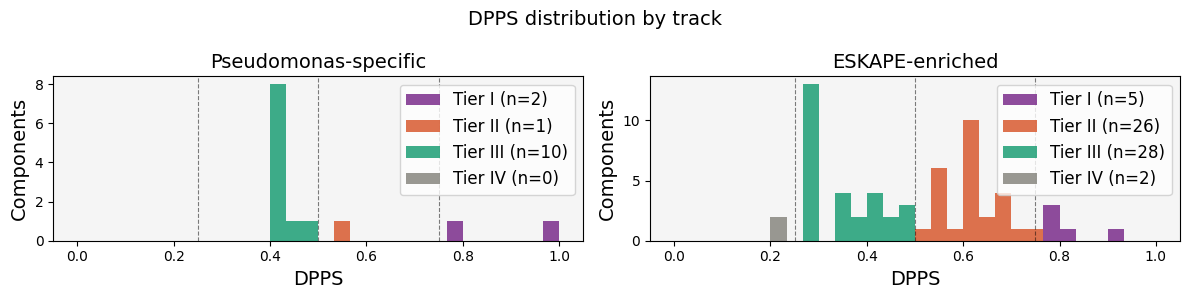

Saved: dpps_distribution_both_tracks.pdf


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, comp_scored, title in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        [f'{GENUS}-specific', 'ESKAPE-enriched']):
    bins = np.linspace(0, 1, 31)
    for tier, color in TIER_COLORS.items():
        subset = comp_scored.loc[comp_scored['tier'] == tier, 'DPPS']
        ax.hist(subset, bins=bins, color=color, alpha=0.85,
                label=f'Tier {tier} (n={len(subset)})')
    for b in TIER_BINS[1:-1]:
        ax.axvline(b, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('DPPS', fontsize=14)
    ax.set_ylabel('Components', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=12)
    ax.set_facecolor('#F5F5F5')
fig.suptitle('DPPS distribution by track', fontsize=14)
fig.tight_layout()
plt.savefig('./dpps_distribution_both_tracks.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: dpps_distribution_both_tracks.pdf')

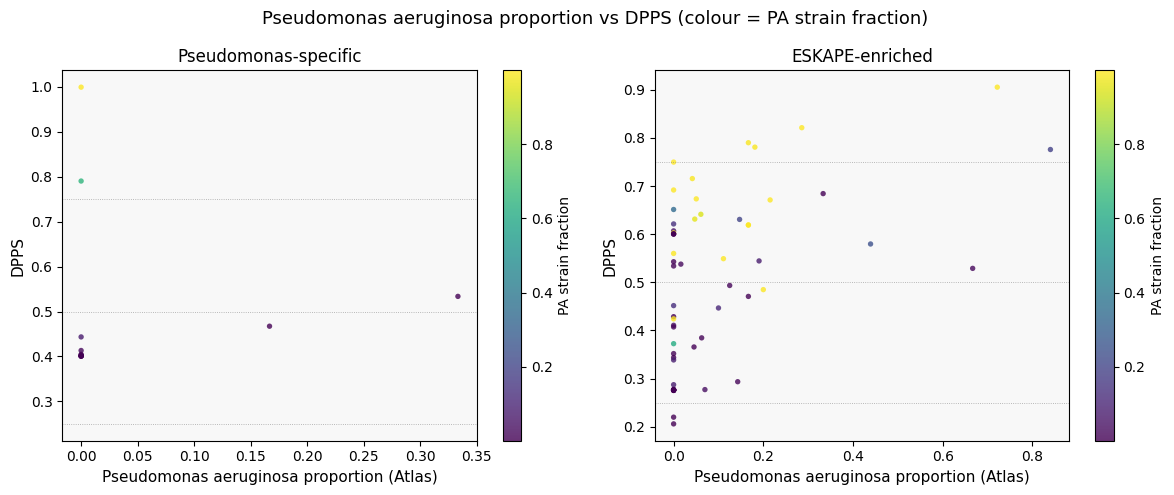

Saved: dpps_pa_proportion_scatter.pdf


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, comp_scored, title in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        [f'{GENUS}-specific', 'ESKAPE-enriched']):
    scatter = ax.scatter(
        comp_scored[SPECIES_COL],
        comp_scored['DPPS'],
        c=comp_scored['PA_strain_fraction'],
        cmap='viridis', s=15, alpha=0.8, linewidths=0
    )
    for b in TIER_BINS[1:-1]:
        ax.axhline(b, color='gray', linewidth=0.6, linestyle=':', alpha=0.7)
    plt.colorbar(scatter, ax=ax, label=f'{SPECIES_ABBR} strain fraction')
    ax.set_xlabel(f'{SPECIES} proportion (Atlas)', fontsize=11)
    ax.set_ylabel('DPPS', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_facecolor('#F8F8F8')
fig.suptitle(f'{SPECIES} proportion vs DPPS (colour = {SPECIES_ABBR} strain fraction)', fontsize=13)
fig.tight_layout()
plt.savefig('./dpps_pa_proportion_scatter.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: dpps_pa_proportion_scatter.pdf')

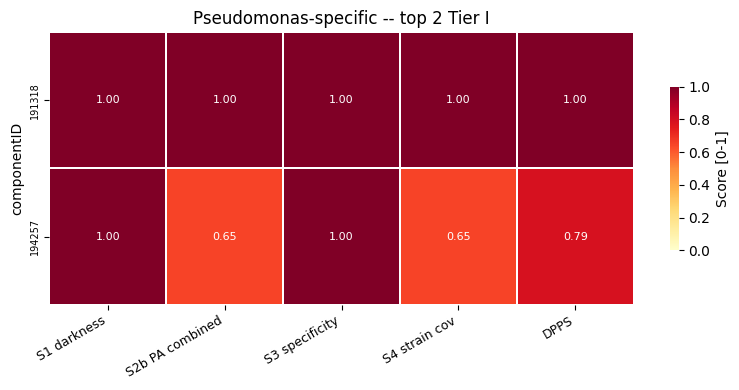

Saved: ./dpps_heatmap_pseudomonas_specific.pdf


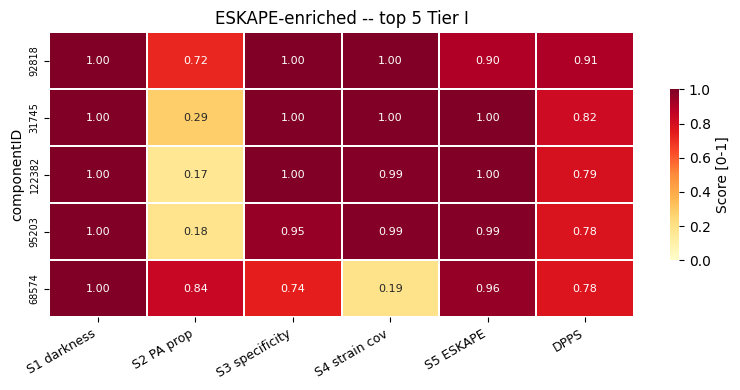

Saved: ./dpps_heatmap_eskape_enriched.pdf


In [65]:
def score_heatmap(comp_scored, score_cols, xlabels, title, fname):
    top = comp_scored[comp_scored['tier'] == 'I'].head(30)
    if len(top) == 0:
        top = comp_scored.head(30)
        print(f'No Tier I found -- showing top 30 overall for {title}')
    # Keep only columns that actually exist
    score_cols = [c for c in score_cols if c in top.columns]
    data = top.set_index('componentID')[score_cols]
    fig, ax = plt.subplots(figsize=(8, max(4, len(top) * 0.30)))
    sns.heatmap(data, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                linewidths=0.3, linecolor='white',
                cbar_kws={'label': 'Score [0-1]', 'shrink': 0.6})
    ax.set_title(f'{title} -- top {len(top)} Tier I', fontsize=12)
    ax.set_xticklabels(xlabels[:len(score_cols)], rotation=30, ha='right', fontsize=9)
    ax.tick_params(axis='y', labelsize=7)
    fig.tight_layout()
    plt.savefig(fname, bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {fname}')

score_heatmap(
    comp_ps_scored,
    ['S1_darkness', 'S2b_pa_combined', 'S3_specificity', 'S4_pa_strain_coverage', 'DPPS'],
    ['S1 darkness', f'S2b {SPECIES_ABBR} combined', 'S3 specificity', 'S4 strain cov', 'DPPS'],
    f'{GENUS}-specific',
    './dpps_heatmap_pseudomonas_specific.pdf'
)

score_heatmap(
    comp_es_scored,
    ['S1_darkness', 'S2_pa_proportion', 'S3_specificity', 'S4_pa_strain_coverage', 'S5_eskape_enrich', 'DPPS'],
    ['S1 darkness', f'S2 {SPECIES_ABBR} prop', 'S3 specificity', 'S4 strain cov', 'S5 ESKAPE', 'DPPS'],
    'ESKAPE-enriched',
    './dpps_heatmap_eskape_enriched.pdf'
)


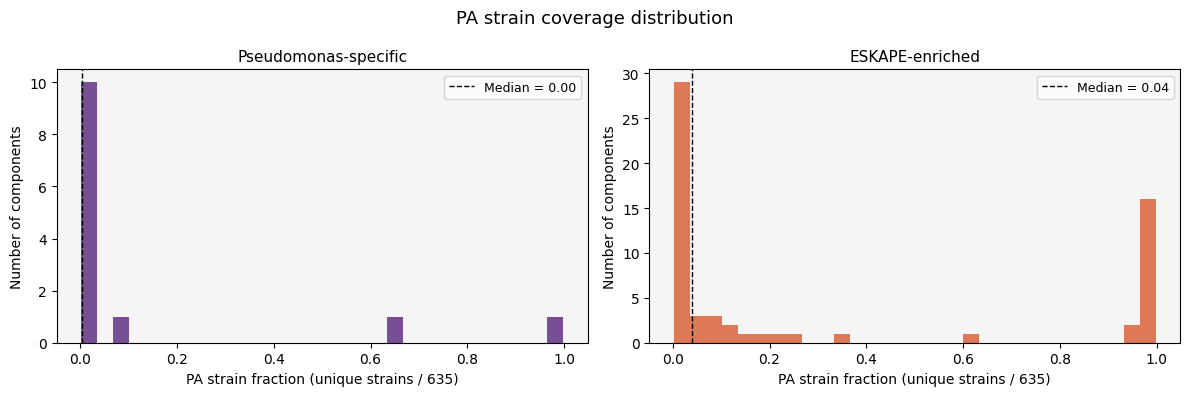

Saved: pa_strain_coverage_distribution.pdf


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, comp_scored, title, color in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        [f'{GENUS}-specific', 'ESKAPE-enriched'],
        ['#57257F', '#D85A30']):
    ax.hist(comp_scored['PA_strain_fraction'], bins=30,
            color=color, alpha=0.8, edgecolor='none')
    median_sf = comp_scored['PA_strain_fraction'].median()
    ax.axvline(median_sf, color='black', linewidth=1, linestyle='--',
               label=f'Median = {median_sf:.2f}')
    ax.set_xlabel(f'{SPECIES_ABBR} strain fraction (unique strains / {N_STRAINS})', fontsize=10)
    ax.set_ylabel('Number of components', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_facecolor('#F5F5F5')
fig.suptitle(f'{SPECIES_ABBR} strain coverage distribution', fontsize=13)
fig.tight_layout()
plt.savefig('./pa_strain_coverage_distribution.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: pa_strain_coverage_distribution.pdf')

In [67]:
print('=' * 65)
print('ECLIPSE Part III -- Summary')
print('=' * 65)

for track, df_raw, df_filt, comp_s, reps_s in [
    (f'{GENUS}-specific', df_ps, df_ps_filt, comp_ps_scored, reps_ps_scored),
    ('ESKAPE-enriched',      df_es, df_es_filt, comp_es_scored, reps_es_scored),
]:
    print(f'\n--- {track} ---')
    print(f'  Input from Part II:    {len(df_raw):,} proteins, '
          f'{df_raw["componentID"].nunique():,} components')
    print(f'  After length filter:   {len(df_filt):,} proteins, '
          f'{df_filt["componentID"].nunique():,} components')
    print(f'  After clustering:      {len(reps_s):,} representatives')
    for tier in ['I', 'II', 'III', 'IV']:
        n = int((comp_s['tier'] == tier).sum())
        m = comp_s.loc[comp_s['tier'] == tier, 'DPPS'].mean()
        print(f'  Tier {tier}: {n:>4,} components  mean DPPS = {m:.3f}')

print()
print(f'Top 5 -- {GENUS}-specific:')
ps_cols = ['componentID', 'DPPS', 'tier', 'S2b_pa_combined',
           'S3_specificity', 'S4_pa_strain_coverage', 'PA_strain_count',
           SPECIES_COL]
ps_cols = [c for c in ps_cols if c in comp_ps_scored.columns]
print(comp_ps_scored[ps_cols].head(5).round(3).to_string(index=False))

print()
print('Top 5 -- ESKAPE-enriched:')
es_cols = ['componentID', 'DPPS', 'tier', 'S2_pa_proportion', 'S5_eskape_enrich',
           'S4_pa_strain_coverage', 'PA_strain_count', SPECIES_COL]
es_cols = [c for c in es_cols if c in comp_es_scored.columns]
print(comp_es_scored[es_cols].head(5).round(3).to_string(index=False))


ECLIPSE Part III -- Summary

--- Pseudomonas-specific ---
  Input from Part II:    13,230 proteins, 83 components
  After length filter:   1,471 proteins, 13 components
  After clustering:      20 representatives
  Tier I:    2 components  mean DPPS = 0.895
  Tier II:    1 components  mean DPPS = 0.534
  Tier III:   10 components  mean DPPS = 0.414
  Tier IV:    0 components  mean DPPS = nan

--- ESKAPE-enriched ---
  Input from Part II:    39,452 proteins, 215 components
  After length filter:   15,078 proteins, 61 components
  After clustering:      102 representatives
  Tier I:    5 components  mean DPPS = 0.815
  Tier II:   26 components  mean DPPS = 0.615
  Tier III:   28 components  mean DPPS = 0.350
  Tier IV:    2 components  mean DPPS = 0.213

Top 5 -- Pseudomonas-specific:
 componentID  DPPS tier  S2b_pa_combined  S3_specificity  S4_pa_strain_coverage  PA_strain_count  p_aeruginosa_proportion
      191318 0.999    I            0.998             1.0                  0.998     

In [68]:
# Inspect strain coverage for any specific component of interest.
# Works for both Format A (prefix method) and Format B (filename mapping).
# Change INSPECT_COMPONENT to any componentID you want to examine.
# Change INSPECT_TRACK to "ps" for genus-specific or "es" for ESKAPE-enriched.

INSPECT_COMPONENT = 92818   # replace with any componentID
INSPECT_TRACK     = "es"    # "ps" = genus-specific, "es" = ESKAPE-enriched

# Select the right dataframe
df_inspect_src = df_ps_filt if INSPECT_TRACK == "ps" else df_es_filt
comp_inspect = df_inspect_src[df_inspect_src["componentID"] == INSPECT_COMPONENT].copy()

if len(comp_inspect) == 0:
    print(f"Component {INSPECT_COMPONENT} not found in {INSPECT_TRACK} track after length filter.")
    print("Try a different componentID or switch INSPECT_TRACK.")
else:
    if _fmt == "prefix":
        # Format A -- extract strain from queryID prefix (P. aeruginosa method)
        has_underscore = comp_inspect["queryID"].str.contains("_", regex=False)
        comp_inspect = comp_inspect[has_underscore].copy()
        comp_inspect["strain"] = comp_inspect["queryID"].str.split("_").str[0]
    else:
        # Format B -- join from queryID_to_strain.csv
        comp_inspect = comp_inspect.merge(_strain_map, on="queryID", how="left")

    if "strain" not in comp_inspect.columns or comp_inspect["strain"].isna().all():
        print(f"No strain information available for component {INSPECT_COMPONENT}.")
        print("For Format B: check that queryID_to_strain.csv was generated by Part I Cell 40.")
        print("For Format A: check that queryIDs contain underscore separators.")
    else:
        strain_counts = (
            comp_inspect.groupby("strain")["queryID"]
            .count()
            .sort_values(ascending=False)
        )
        print(f"Component {INSPECT_COMPONENT} ({INSPECT_TRACK} track) -- proteins per strain (top 20):")
        print(strain_counts.head(20))
        print()
        print(f"Total proteins        : {len(comp_inspect)}")
        print(f"Total unique strains  : {comp_inspect['strain'].nunique()}")
        print(f"Unmapped proteins     : {comp_inspect['strain'].isna().sum()}")
        print(f"Strain fraction (S4)  : {comp_inspect['strain'].nunique() / N_STRAINS:.3f}")


Component 92818 (es track) -- proteins per strain (top 20):
strain
A0K      2
MN180    2
MMZ73    2
MMZ75    2
MMZ76    2
MMZ77    2
MN130    2
MN178    2
MN179    2
MO979    2
MMZ71    2
MO982    2
MO986    2
MON07    2
MPAO1    2
MS088    2
MS095    2
MTX71    2
MMZ72    2
MMZ70    2
Name: queryID, dtype: int64

Total proteins        : 1261
Total unique strains  : 634
Unmapped proteins     : 0
Strain fraction (S4)  : 0.998


Tier I stability scores:
  Pseudomonas-specific:
 componentID  DPPS  tier1_stability
      191318 0.999            1.000
      194257 0.790            0.776
  ESKAPE-enriched:
 componentID  DPPS  tier1_stability
       92818 0.905            1.000
       31745 0.821            0.824
      122382 0.790            0.754
       95203 0.781            0.744
       68574 0.776            0.566


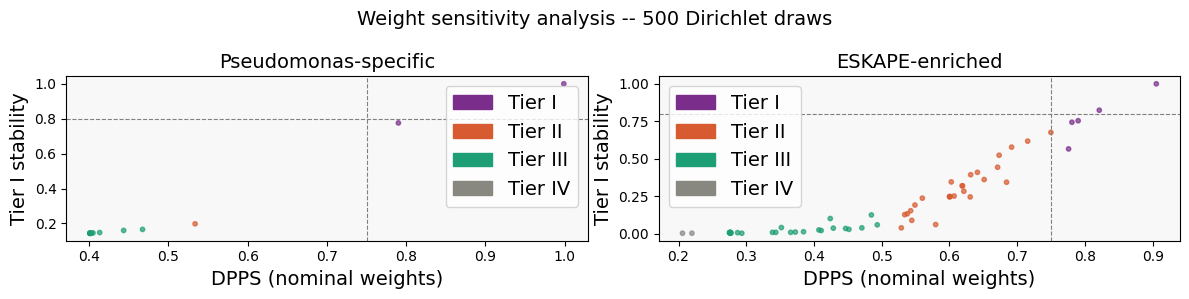

Saved: dpps_sensitivity_both_tracks.pdf


In [69]:
def sensitivity_analysis(comp_scored, weight_keys, n_boot=500):
    np.random.seed(42)
    n_scores = len(weight_keys)
    # Only use columns that exist in comp_scored
    weight_keys = [k for k in weight_keys if k in comp_scored.columns]
    score_matrix = comp_scored[weight_keys].values
    tier1_freq = np.zeros(len(comp_scored))
    for _ in range(n_boot):
        w = np.random.dirichlet(np.ones(n_scores))
        dpps_boot = np.clip(score_matrix @ w, 0, 1)
        tier1_freq += (dpps_boot >= 0.75).astype(float)
    comp_out = comp_scored.copy()
    comp_out['tier1_stability'] = tier1_freq / n_boot
    return comp_out

comp_ps_scored = sensitivity_analysis(comp_ps_scored, list(WEIGHTS_PS.keys()))
comp_es_scored = sensitivity_analysis(comp_es_scored, list(WEIGHTS_ES.keys()))

# Print stability for Tier I candidates
print('Tier I stability scores:')
for comp_s, track in [(comp_ps_scored, f'{GENUS}-specific'),
                       (comp_es_scored, 'ESKAPE-enriched')]:
    tier1 = comp_s[comp_s['tier'] == 'I'][['componentID', 'DPPS', 'tier1_stability']]
    if len(tier1) > 0:
        print(f'  {track}:')
        print(tier1.round(3).to_string(index=False))
    else:
        print(f'  {track}: no Tier I components')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, comp_scored, title in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        [f'{GENUS}-specific', 'ESKAPE-enriched']):
    ax.scatter(comp_scored['DPPS'], comp_scored['tier1_stability'],
               c=[TIER_COLORS.get(t, 'gray') for t in comp_scored['tier']],
               s=10, alpha=0.7)
    ax.axhline(0.8, linestyle='--', color='gray', linewidth=0.8, label='80% stability')
    ax.axvline(0.75, linestyle='--', color='gray', linewidth=0.8)
    ax.set_xlabel('DPPS (nominal weights)', fontsize=14)
    ax.set_ylabel('Tier I stability', fontsize=14)
    ax.set_title(title, fontsize=14)
    patches = [mpatches.Patch(color=c, label=f'Tier {t}') for t, c in TIER_COLORS.items()]
    ax.legend(handles=patches, fontsize=14)
    ax.set_facecolor('#F8F8F8')
fig.suptitle('Weight sensitivity analysis -- 500 Dirichlet draws', fontsize=14)
fig.tight_layout()
plt.savefig('./dpps_sensitivity_both_tracks.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: dpps_sensitivity_both_tracks.pdf')
